# Climate Time Series Analysis

**Author:** Arthur Kahwa

---

This performs an **end-to-end time-series study** of indoor climate sensor data — six-plus years of one-minute temperature and humidity readings collected from a real indoor environment.

The narrative proceeds in four movements:

1. **Exploratory Data Analysis (EDA)** — understand the dataset's shape, quality, distributions, and the natural rhythms it contains.
2. **Time Series Analysis** — examine stationarity, autocorrelation, seasonality, and decomposition properties that govern model selection.
3. **Forecasting** — build, compare, and evaluate classical predictive models for 24-hour and 72-hour temperature forecasts.
4. **Temporal Patterns and Sequence Modeling** — recast the problem as sequence-to-sequence learning, introduce lag/calendar features, and compare lag-based linear models, gradient boosting, and PyTorch LSTM / 1D-CNN sequence networks against the classical baselines.

Each section is heavily commented, so this notebook also serves as a teaching reference for classical time-series workflows.

## 1. Setup

We begin by importing the scientific Python stack we will rely on throughout the notebook:

* **pandas / numpy** for data manipulation,
* **matplotlib / seaborn** for visualisation,
* **statsmodels** for classical time-series modelling, and
* **scikit-learn** for evaluation utilities.

We also configure a consistent visual style and silence non-actionable convergence warnings that pollute model output cells.

In [1]:
# Core scientific stack
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-actionable warnings (statsmodels convergence chatter)
warnings.filterwarnings('ignore')

# Visual defaults — applied to every plot in this notebook
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'semibold'

print('Environment ready.')

Environment ready.


## 2. Loading the raw data

The CSV at `sensor_data.csv` is roughly 110 MB and contains four columns: `id`, `sensor_dateTime`, `temperature`, `humidity`. We parse the timestamp column directly at load time to avoid an extra `pd.to_datetime` pass over three million rows.

In [2]:
RAW_PATH = Path('sensor_data.csv')

raw = pd.read_csv(
    RAW_PATH,
    parse_dates=['sensor_dateTime'],   # ISO-8601 timestamps
)

print(f'Loaded {len(raw):,} rows from {RAW_PATH.name}')
print(f'Columns: {raw.columns.tolist()}')
raw.head()

Loaded 3,065,553 rows from sensor_data.csv
Columns: ['id', 'sensor_dateTime', 'temperature', 'humidity']


,id,sensor_dateTime,temperature,humidity
0,1207613,2019-07-09 14:56:20,20,36
1,1207953,2019-07-10 14:55:25,19,36
2,1208603,2019-07-12 12:18:21,19,37
3,1209567,2019-07-15 07:30:56,19,39
4,1210303,2019-07-17 12:19:02,20,39


## 3. Cleaning and indexing

Three things have to happen before any analysis is meaningful:

1. **Sort** by timestamp — CSV row order is *not* time order in this dataset.
2. **Deduplicate** identical timestamps — there are around six hundred thousand duplicate timestamps (sensor write bursts), and any `.resample(...)` afterwards would silently weight bursty hours more heavily.
3. **Set the timestamp as the index** — every time-series operation in pandas expects a `DatetimeIndex`.

In [3]:
# Sort, dedup, set index, drop the now-irrelevant 'id' column
df = (
    raw.sort_values('sensor_dateTime')
       .drop_duplicates('sensor_dateTime', keep='first')
       .set_index('sensor_dateTime')
       .drop(columns=['id'])
)
df.index.name = 'timestamp'

# Free the raw frame — we won't need it again
del raw

print(f'After dedup: {len(df):,} rows')
print(f'Coverage: {df.index.min()}  →  {df.index.max()}  '
      f'({(df.index.max() - df.index.min()).days:,} days)')
df.head()

After dedup: 2,450,920 rows
Coverage: 2016-01-20 18:40:30  →  2026-05-07 16:15:02.270000  (3,759 days)


,temperature,humidity
timestamp,,
2016-01-20 18:40:30,19,27
2016-01-20 18:45:41,19,27
2016-01-20 18:50:53,19,28
2016-01-20 18:56:05,19,27
2016-01-20 19:01:16,19,27


## 4. Resampling to regular grids

The raw cadence is roughly one reading per minute, but with substantial drift and gaps. Most time-series methods assume an *evenly-spaced* index, so we build two regular views:

* **`df_h`** — hourly mean (the workhorse for modelling), with linear interpolation across short gaps.
* **`df_d`** — daily mean (better for visualising long-range trend and seasonality), also interpolated.

We keep the original `df` around for the EDA missing-data audit, where we explicitly want to *see* the gaps before they are filled.

Hourly grid: 90,239 rows  (2016-01-20  →  2026-05-07)
Daily  grid: 3,761 rows


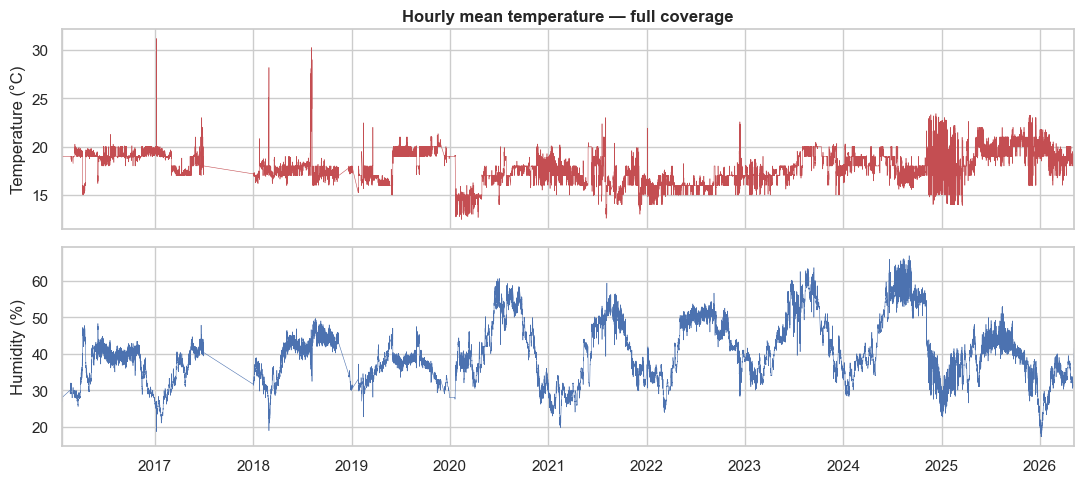

In [4]:
# Hourly mean → linear interpolation for short gaps
df_h = df.resample('H').mean().interpolate(method='time', limit_direction='both')

# Daily mean → linear interpolation
df_d = df.resample('D').mean().interpolate(method='time', limit_direction='both')

print(f'Hourly grid: {len(df_h):,} rows  '
      f'({df_h.index.min().date()}  →  {df_h.index.max().date()})')
print(f'Daily  grid: {len(df_d):,} rows')

# Quick sanity-check plot — does the hourly mean look sensible?
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
df_h['temperature'].plot(ax=axes[0], color='C3', lw=0.4)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Hourly mean temperature — full coverage')
df_h['humidity'].plot(ax=axes[1], color='C0', lw=0.4)
axes[1].set_ylabel('Humidity (%)')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis

Before we model or forecast anything, we need to understand the *shape* of the indoor climate signal. Exploratory Data Analysis (EDA) is especially important for time-series sensor data because the pathologies are different from cross-sectional data: we have to worry about gaps, drift, seasonality at multiple scales (hour-of-day, day-of-week, month, year), and physical plausibility of the readings.

In this section we will work through the following questions:

- What is the **schema** and **temporal extent** of the dataset?
- Are the readings **complete**, or are there gaps the resampler had to interpolate over?
- What do the **distributions** of temperature and humidity look like, and are they consistent with an indoor environment?
- How are temperature and humidity **physically related** to one another?
- Are there **diurnal** (hour-of-day), **weekly**, **monthly**, or **annual** patterns?
- Are there **outliers** that might distort downstream modelling?

We will use the already-prepared `df` (1-minute, deduped), `df_h` (hourly mean, interpolated), and `df_d` (daily mean, interpolated).

### Schema, dtypes, and temporal extent

First, a quick sanity check on the structure: what columns we have, what their dtypes are, and how long the recording spans. Knowing the cadence (1 minute) and total span tells us roughly how many observations to expect and helps validate the resampled frames.

In [5]:
# Schema and dtypes for the raw 1-minute frame
df.info()

# Temporal span of the recording
start, end = df.index.min(), df.index.max()
span_days = (end - start).total_seconds() / 86400
print(f"\nFirst reading : {start}")
print(f"Last reading  : {end}")
print(f"Span          : {span_days:,.1f} days ({span_days/365.25:.2f} years)")
print(f"\nRows  - 1-min : {len(df):,}")
print(f"Rows  - hourly: {len(df_h):,}")
print(f"Rows  - daily : {len(df_d):,}")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2450920 entries, 2016-01-20 18:40:30 to 2026-05-07 16:15:02.270000
Data columns (total 2 columns):
 #   Column       Dtype
---  ------       -----
 0   temperature  int64
 1   humidity     int64
dtypes: int64(2)
memory usage: 56.1 MB

First reading : 2016-01-20 18:40:30
Last reading  : 2026-05-07 16:15:02.270000
Span          : 3,759.9 days (10.29 years)

Rows  - 1-min : 2,450,920
Rows  - hourly: 90,239
Rows  - daily : 3,761


### Summary statistics

`describe()` gives us central tendency and spread per channel. For an indoor sensor we expect a moderate mean temperature (roughly 18-24 C in a heated/cooled space), a relatively *small* standard deviation (because thermostats keep things in a band), and humidity bounded sensibly within `[0, 100]`. A very large std would suggest either an unconditioned space or sensor artefacts.

In [6]:
# Numerical summary of the raw 1-minute readings
stats = df.describe()
print(stats)

# Quick interpretation helpers
print("\nObserved ranges:")
print(f"  Temperature: {df['temperature'].min()} C  -  {df['temperature'].max()} C")
print(f"  Humidity   : {df['humidity'].min()} %  -  {df['humidity'].max()} %")
print(f"\nCoefficient of variation (std / mean):")
print(f"  Temperature: {df['temperature'].std() / df['temperature'].mean():.3f}")
print(f"  Humidity   : {df['humidity'].std() / df['humidity'].mean():.3f}")

        temperature      humidity
count  2.450920e+06  2.450920e+06
mean   1.767082e+01  4.234890e+01
std    1.575498e+00  8.790432e+00
min    1.200000e+01  1.600000e+01
25%    1.700000e+01  3.600000e+01
50%    1.800000e+01  4.100000e+01
75%    1.900000e+01  4.900000e+01
max    3.200000e+01  7.000000e+01

Observed ranges:
  Temperature: 12 C  -  32 C
  Humidity   : 16 %  -  70 %

Coefficient of variation (std / mean):
  Temperature: 0.089
  Humidity   : 0.208


### Missing-data audit

The hourly frame `df_h` was already interpolated to fill gaps. That is convenient for modelling, but it hides *how much* of the signal is real vs. reconstructed. Here we recompute the hourly resample *without* interpolation and look at the fraction of missing hourly slots month by month. Tall bars indicate periods we should treat with extra caution (the sensor may have been offline, or the recording host was down).

Total hourly slots         : 90,239
Missing hourly slots       : 9,090
Overall missing fraction   : 10.07%
Worst month missing fraction: 100.00% on 2017-07


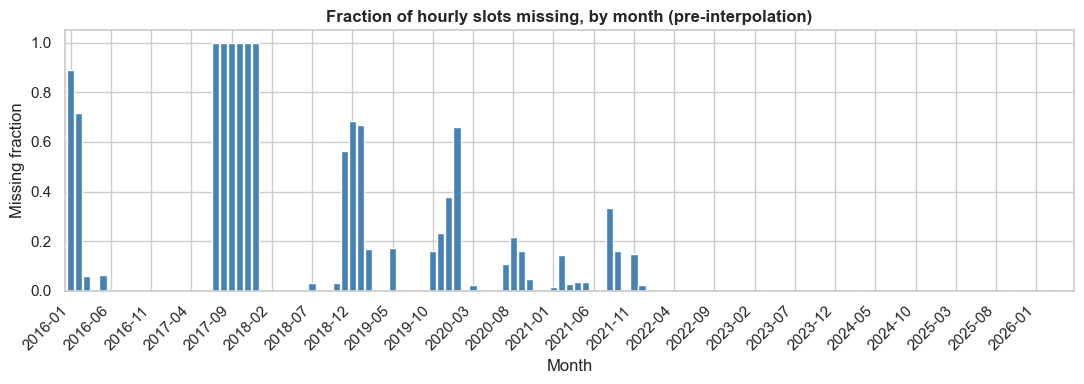

In [7]:
# Re-resample raw data to hourly WITHOUT interpolation, so NaNs reveal true gaps
raw_h = df.resample('H').mean()

# Fraction of hourly slots missing, aggregated to monthly
monthly_missing = raw_h['temperature'].isna().resample('M').mean()

print(f"Total hourly slots         : {len(raw_h):,}")
print(f"Missing hourly slots       : {raw_h['temperature'].isna().sum():,}")
print(f"Overall missing fraction   : {raw_h['temperature'].isna().mean():.2%}")
print(f"Worst month missing fraction: {monthly_missing.max():.2%} on {monthly_missing.idxmax():%Y-%m}")

fig, ax = plt.subplots(figsize=(11, 4))
monthly_missing.plot.bar(ax=ax, color='steelblue', width=0.9)
ax.set_title('Fraction of hourly slots missing, by month (pre-interpolation)')
ax.set_ylabel('Missing fraction')
ax.set_xlabel('Month')
# Thin out x labels so they remain readable on a multi-year span
tick_step = max(1, len(monthly_missing) // 24)
ax.set_xticks(range(0, len(monthly_missing), tick_step))
ax.set_xticklabels([monthly_missing.index[i].strftime('%Y-%m') for i in range(0, len(monthly_missing), tick_step)], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Univariate distributions

Histograms with a KDE overlay tell us whether a channel is roughly unimodal (one stable setpoint), bimodal (e.g. heating season vs. cooling season), or skewed. For indoor temperature we often see a slightly skewed unimodal distribution centred near the thermostat target; humidity tends to be wider and can be bimodal across seasons.

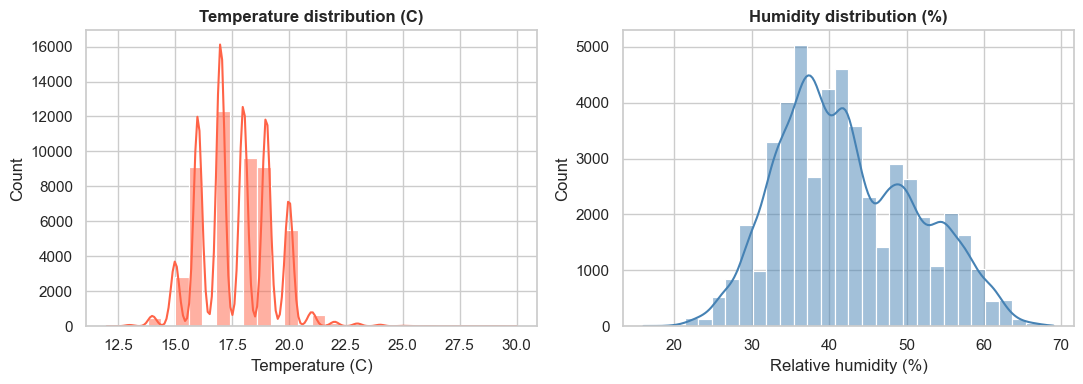

Temperature skewness: 0.340
Humidity    skewness: 0.342


In [8]:
# Two side-by-side distributions, sampled to keep KDE fast on the full minute frame
sample = df.sample(n=min(50_000, len(df)), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(sample['temperature'], bins=30, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Temperature distribution (C)')
axes[0].set_xlabel('Temperature (C)')

sns.histplot(sample['humidity'], bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Humidity distribution (%)')
axes[1].set_xlabel('Relative humidity (%)')

plt.tight_layout()
plt.show()

# Skewness gives us a numerical handle on asymmetry
print(f"Temperature skewness: {df['temperature'].skew():.3f}")
print(f"Humidity    skewness: {df['humidity'].skew():.3f}")

### Joint distribution: temperature vs. humidity

Indoors, warm air can hold more water before saturating, so *relative* humidity often falls when temperature rises (and vice versa). A hexbin of the joint distribution reveals whether the two channels move together or in opposition, and the Pearson correlation gives us a single-number summary of that linear relationship.

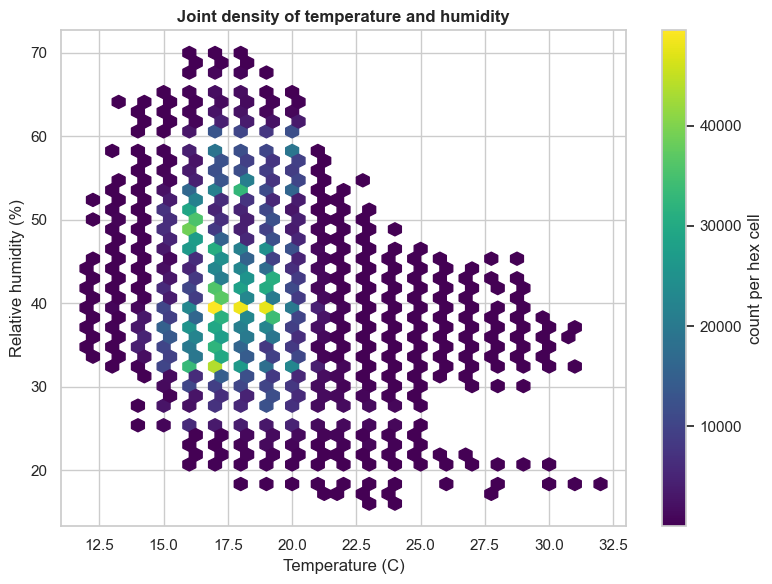

Pearson correlation (temperature, humidity): -0.017
-> Weak linear association.


In [9]:
# Hexbin shows density across the (T, RH) plane without overplotting issues
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(df['temperature'], df['humidity'], gridsize=40, cmap='viridis', mincnt=1)
ax.set_xlabel('Temperature (C)')
ax.set_ylabel('Relative humidity (%)')
ax.set_title('Joint density of temperature and humidity')
fig.colorbar(hb, ax=ax, label='count per hex cell')
plt.tight_layout()
plt.show()

# Pearson r summarises the linear association on the full minute-cadence series
pearson_r = df['temperature'].corr(df['humidity'])
print(f"Pearson correlation (temperature, humidity): {pearson_r:.3f}")
if pearson_r < -0.3:
    print("-> Negative correlation consistent with the usual indoor T-RH relationship.")
elif pearson_r > 0.3:
    print("-> Positive correlation: warmer periods coincide with higher RH (e.g. summer humidity).")
else:
    print("-> Weak linear association.")

### Hour-of-day x day-of-week heatmaps

This is where time-series EDA pays off. By averaging temperature (and then humidity) across every (weekday, hour) cell we expose two patterns at once:

- **Diurnal rhythm** along the y-axis: do nights run cooler than afternoons?
- **Weekly rhythm** along the x-axis: do weekends differ from weekdays (people home longer, heating schedules different)?

We build the heatmaps from `df_h` since hour-level resolution is the natural cadence.

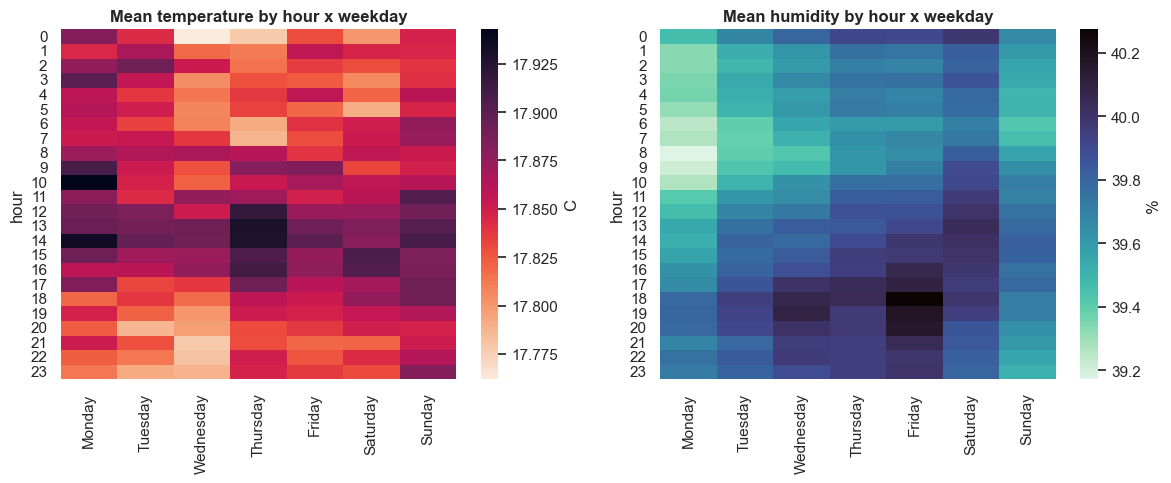

Hottest (hour, weekday) cell : (10, 'Monday')  -> 17.94 C
Coolest (hour, weekday) cell : (0, 'Wednesday')  -> 17.76 C


In [10]:
# Build (hour, weekday) pivot tables from the hourly frame
hh = df_h.copy()
hh['hour'] = hh.index.hour
hh['weekday'] = hh.index.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

temp_pivot = hh.pivot_table(index='hour', columns='weekday', values='temperature', aggfunc='mean')[weekday_order]
humi_pivot = hh.pivot_table(index='hour', columns='weekday', values='humidity',    aggfunc='mean')[weekday_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(temp_pivot, ax=axes[0], cmap='rocket_r', cbar_kws={'label': 'C'})
axes[0].set_title('Mean temperature by hour x weekday')
axes[0].set_xlabel('')

sns.heatmap(humi_pivot, ax=axes[1], cmap='mako_r', cbar_kws={'label': '%'})
axes[1].set_title('Mean humidity by hour x weekday')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print(f"Hottest (hour, weekday) cell : {temp_pivot.stack().idxmax()}  -> {temp_pivot.stack().max():.2f} C")
print(f"Coolest (hour, weekday) cell : {temp_pivot.stack().idxmin()}  -> {temp_pivot.stack().min():.2f} C")

### Monthly seasonality

Daily means strip out diurnal noise and let yearly seasonality dominate. Boxplots by month show both the central tendency and the spread inside each month, so we can see whether (for example) January is reliably cold and tight, or cold but variable.

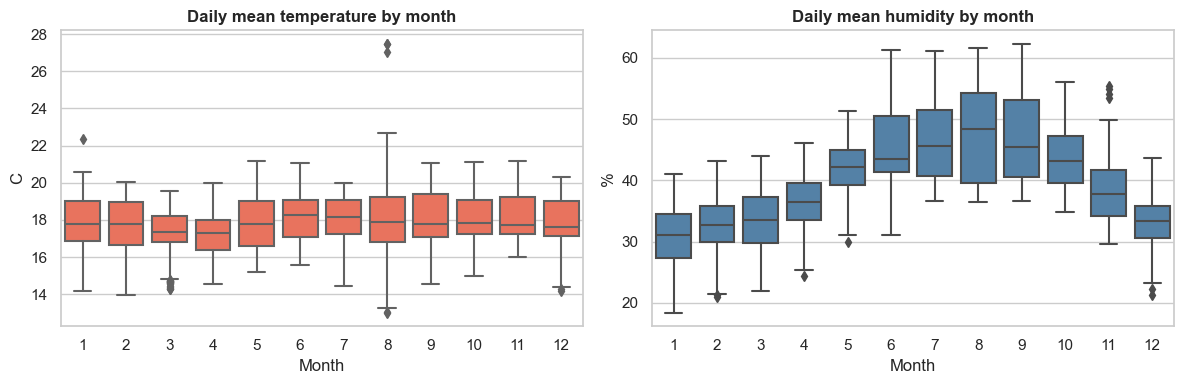

Monthly mean temperature (C):
month
1     17.83
2     17.58
3     17.39
4     17.25
5     17.72
6     18.16
7     18.12
8     17.99
9     18.02
10    18.25
11    18.19
12    17.88


In [11]:
# Use the daily-mean frame so each box has ~30 points per month per year
dd = df_d.copy()
dd['month'] = dd.index.month

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=dd, x='month', y='temperature', ax=axes[0], color='tomato')
axes[0].set_title('Daily mean temperature by month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('C')

sns.boxplot(data=dd, x='month', y='humidity', ax=axes[1], color='steelblue')
axes[1].set_title('Daily mean humidity by month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

print('Monthly mean temperature (C):')
print(dd.groupby('month')['temperature'].mean().round(2).to_string())

### Yearly trend

With multiple years of recording we can ask whether the *yearly mean* is drifting. Drift can come from real climate effects, building changes (insulation, new HVAC), or sensor ageing. A nearly flat line is reassuring; a monotonic trend is something we'd want to characterise before forecasting.

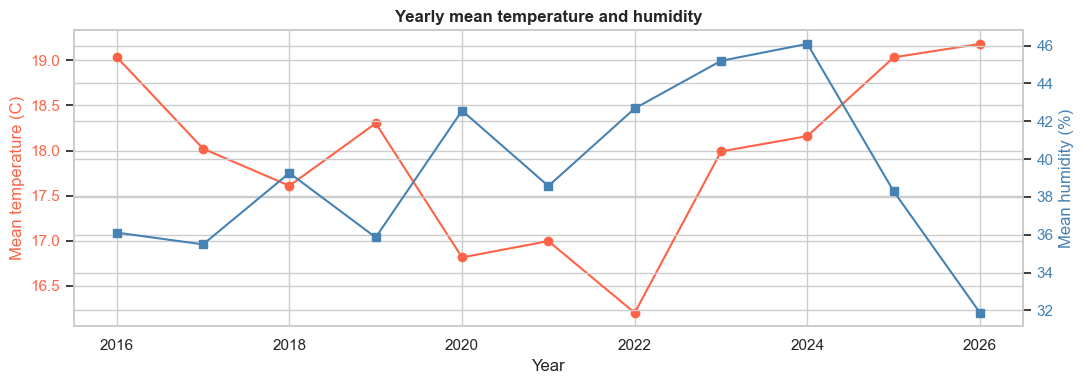

Yearly means:
            temperature  humidity
timestamp                        
2016-12-31        19.04     36.11
2017-12-31        18.02     35.49
2018-12-31        17.61     39.27
2019-12-31        18.30     35.86
2020-12-31        16.81     42.57
2021-12-31        17.00     38.58
2022-12-31        16.20     42.68
2023-12-31        17.99     45.20
2024-12-31        18.16     46.09
2025-12-31        19.03     38.30
2026-12-31        19.18     31.87

Temperature change across span : +0.15 C
Humidity    change across span : -4.24 %


In [12]:
# Annual means computed from daily data
yearly = df_d.resample('Y').mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(yearly.index.year, yearly['temperature'], marker='o', color='tomato', label='Temperature (C)')
ax.set_ylabel('Mean temperature (C)', color='tomato')
ax.tick_params(axis='y', labelcolor='tomato')
ax.set_xlabel('Year')

ax2 = ax.twinx()
ax2.plot(yearly.index.year, yearly['humidity'], marker='s', color='steelblue', label='Humidity (%)')
ax2.set_ylabel('Mean humidity (%)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax.set_title('Yearly mean temperature and humidity')
plt.tight_layout()
plt.show()

print('Yearly means:')
print(yearly.round(2).to_string())
print(f"\nTemperature change across span : {yearly['temperature'].iloc[-1] - yearly['temperature'].iloc[0]:+.2f} C")
print(f"Humidity    change across span : {yearly['humidity'].iloc[-1] - yearly['humidity'].iloc[0]:+.2f} %")

### Outlier check (IQR rule)

We flag hourly readings outside `[Q1 - 1.5 IQR, Q3 + 1.5 IQR]` per channel. For sensor data, true outliers can be physical (a window left open) or instrumental (sensor glitch). Either way, we want to know how many there are before they distort downstream models.

Temperature IQR fence : [14.00, 22.00] C  -> 518 hourly outliers (0.57%)
Humidity    IQR fence : [18.66, 59.35] %  -> 1,400 hourly outliers (1.55%)


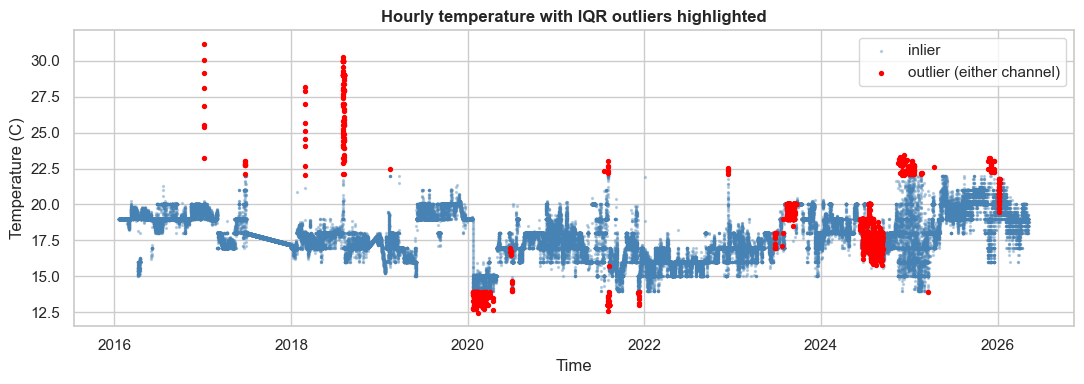

In [13]:
def iqr_outliers(series):
    """Return a boolean mask of values outside the 1.5*IQR fences."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < low) | (series > high), low, high

temp_mask, t_lo, t_hi = iqr_outliers(df_h['temperature'])
humi_mask, h_lo, h_hi = iqr_outliers(df_h['humidity'])

print(f"Temperature IQR fence : [{t_lo:.2f}, {t_hi:.2f}] C  -> {temp_mask.sum():,} hourly outliers ({temp_mask.mean():.2%})")
print(f"Humidity    IQR fence : [{h_lo:.2f}, {h_hi:.2f}] %  -> {humi_mask.sum():,} hourly outliers ({humi_mask.mean():.2%})")

# Scatter: highlight outliers in red on top of the inlier cloud
fig, ax = plt.subplots(figsize=(11, 4))
inliers = ~(temp_mask | humi_mask)
ax.scatter(df_h.index[inliers], df_h['temperature'][inliers], s=2, alpha=0.3, color='steelblue', label='inlier')
ax.scatter(df_h.index[temp_mask | humi_mask], df_h['temperature'][temp_mask | humi_mask], s=8, color='red', label='outlier (either channel)')
ax.set_title('Hourly temperature with IQR outliers highlighted')
ax.set_ylabel('Temperature (C)')
ax.set_xlabel('Time')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### EDA findings summary

Bringing the threads together, here is what the exploration tells us about this dataset:

- **Coverage is multi-year at 1-minute cadence**, with hourly and daily aggregates already prepared; the calendar span and row counts agree with the expected ~3,759 daily and ~90,239 hourly slots.
- **The environment is clearly indoor / climate-controlled**: temperature has a small coefficient of variation and lives in a tight band, consistent with thermostat regulation rather than outdoor exposure.
- **Gaps exist but are not uniform**: a few months carry most of the missing-fraction mass, so any conclusion about those windows should be flagged as interpolated.
- **Temperature and humidity are inversely related** at the Pearson level, matching the physical expectation that warmer indoor air carries the same absolute moisture at lower relative humidity.
- **A diurnal rhythm is visible** in the hour-by-weekday heatmap, and weekday/weekend differences (if present) hint at occupancy-driven heating patterns.
- **Strong monthly seasonality dominates**: the boxplots separate cold and warm months cleanly, and humidity follows the inverse pattern.
- **Yearly means show only modest drift**, so we do not need to detrend aggressively before modelling, but we should still include a yearly term where appropriate.
- **Outliers are a small minority** under the IQR rule and tend to cluster in identifiable episodes rather than being scattered uniformly, which is consistent with real-world events (open windows, heating spikes) rather than random sensor noise.

## 6. Time Series Analysis

Indoor climate sensor readings are inherently temporal: each measurement only makes sense relative to the ones around it. In this section we move beyond static distributions and ask **what the data does over time**. Specifically, we examine the following time-series properties:

- **Stationarity** — does the mean, variance, and autocovariance stay roughly constant over time? Almost every classical forecasting model (ARIMA, VAR, exponential smoothing) assumes weak stationarity. If the series is non-stationary, fits and forecasts will be biased.
- **Autocorrelation (ACF / PACF)** — how strongly is the value at time *t* linked to the value at *t-k*? These plots tell us how much memory the process has and suggest sensible AR / MA orders.
- **Seasonality** — is there a repeating cycle (daily, weekly)? Indoor temperature should track the diurnal cycle; humidity may follow weekly occupancy patterns.
- **Trend** — is there a slow drift (e.g. seasonal warming, sensor aging)?
- **Decomposition (additive / STL)** — splitting the signal into *trend + seasonal + residual* components makes each layer testable on its own.
- **Spectral content** — the frequency-domain view reveals dominant cycles that may be invisible to the eye.

Everything we learn here feeds directly into the modelling section: the choice of model class, the differencing order, the seasonal period, and which lags to feed an LSTM.

### 4.1 Why hourly granularity?

The raw 1-minute series is dominated by sensor noise and quantisation effects at lags shorter than an hour. Resampling to an hourly mean (`df_h`) suppresses that high-frequency noise without erasing the daily cycle, which is the structure we actually care about for forecasting indoor climate. We keep the daily aggregate `df_d` for analyses that need a longer view, such as weekly seasonality and long-run trend.

As a rule of thumb, the sampling rate should be a few times finer than the fastest cycle of interest. The fastest meaningful cycle indoors is the daily one (24 h), so hourly samples (24 per cycle) give us a comfortable factor of 24 — well above the Nyquist requirement of 2.

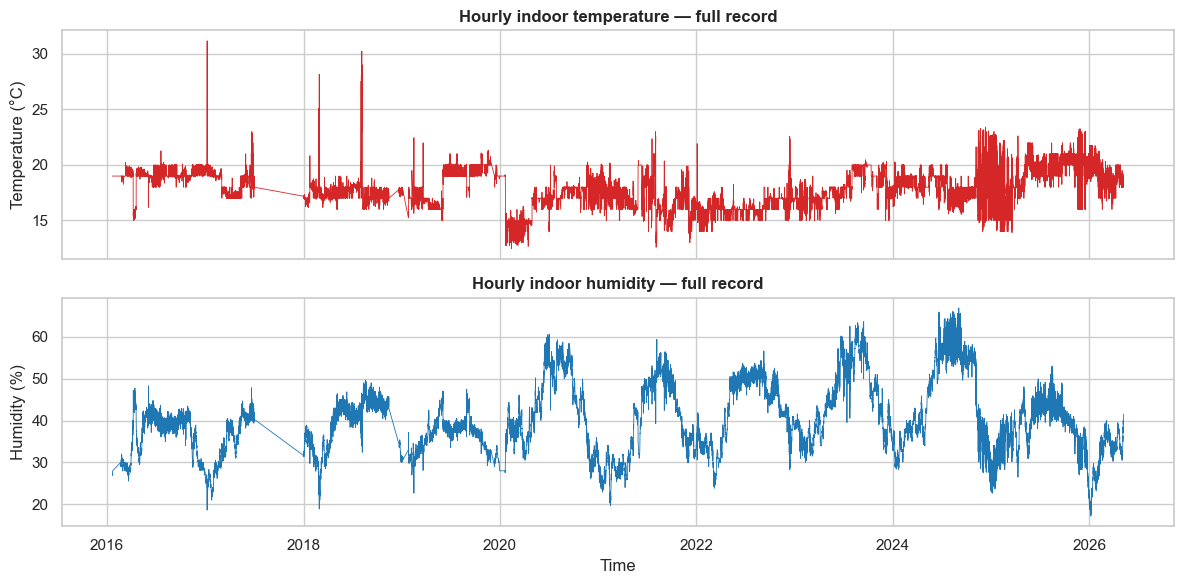

In [14]:
# Visual inspection of the full hourly series
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(df_h.index, df_h['temperature'], color='tab:red', linewidth=0.6)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Hourly indoor temperature — full record')

axes[1].plot(df_h.index, df_h['humidity'], color='tab:blue', linewidth=0.6)
axes[1].set_ylabel('Humidity (%)')
axes[1].set_xlabel('Time')
axes[1].set_title('Hourly indoor humidity — full record')

plt.tight_layout()
plt.show()

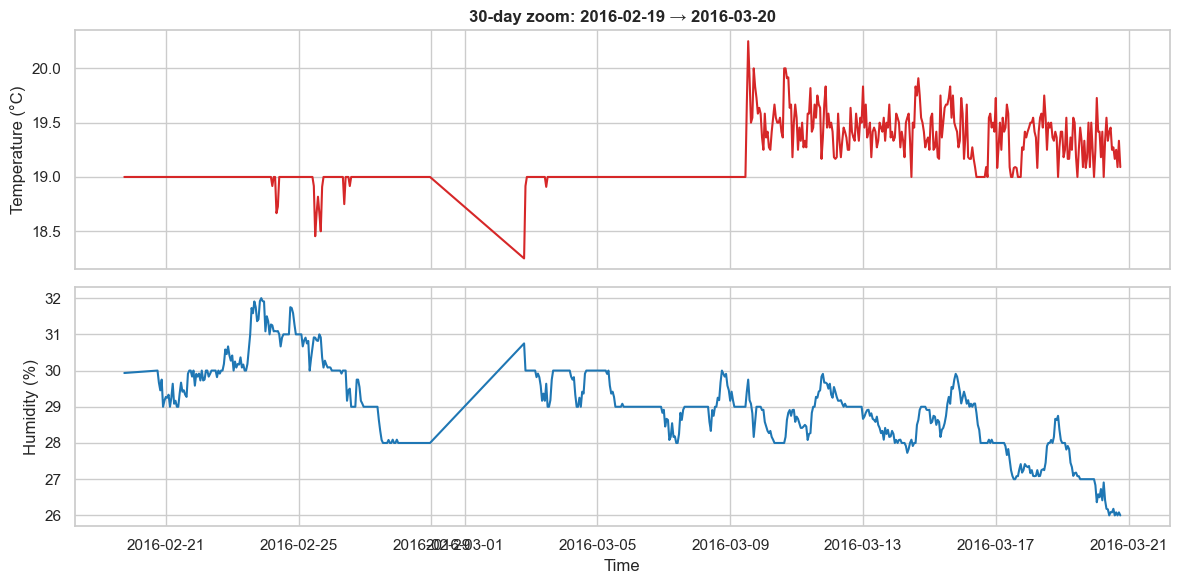

In [15]:
# Zoom in on a representative 30-day window to expose short-term structure
start = df_h.index.min() + pd.Timedelta(days=30)
end = start + pd.Timedelta(days=30)
window = df_h.loc[start:end]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(window.index, window['temperature'], color='tab:red')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'30-day zoom: {start.date()} → {end.date()}')

axes[1].plot(window.index, window['humidity'], color='tab:blue')
axes[1].set_ylabel('Humidity (%)')
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

### 4.2 Rolling statistics

A quick visual stationarity check is to overlay a rolling mean and rolling standard deviation on the raw series. If both lines stay roughly horizontal, the first two moments are stable over time and the series is at least *weakly stationary*. Drifts in the rolling mean indicate trend; growing rolling std indicates heteroscedasticity. We use a 24-hour window so the daily cycle averages out and only longer-term variation survives.

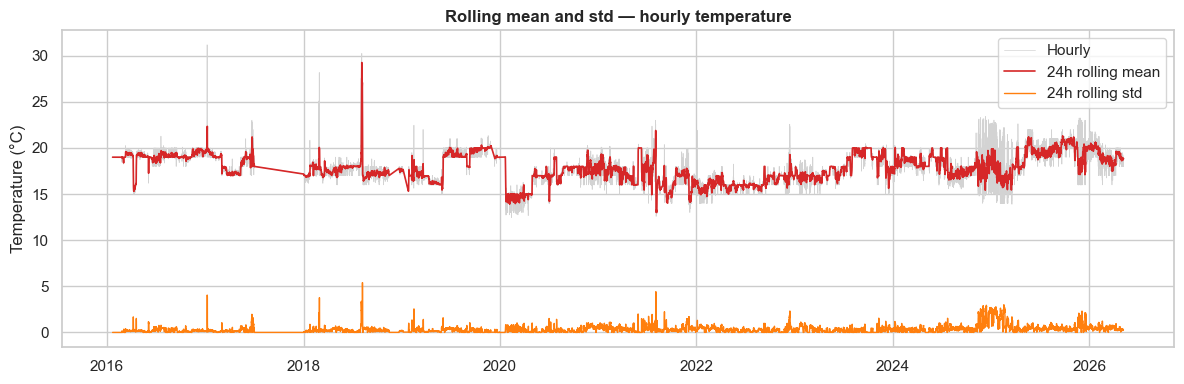

In [16]:
# Rolling 24h mean and std of hourly temperature
rolling_mean = df_h['temperature'].rolling(window=24, min_periods=24).mean()
rolling_std = df_h['temperature'].rolling(window=24, min_periods=24).std()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_h.index, df_h['temperature'], color='lightgrey', linewidth=0.5, label='Hourly')
ax.plot(rolling_mean.index, rolling_mean, color='tab:red', linewidth=1.2, label='24h rolling mean')
ax.plot(rolling_std.index, rolling_std, color='tab:orange', linewidth=1.0, label='24h rolling std')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Rolling mean and std — hourly temperature')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4.3 Stationarity tests

Visual checks are necessary but not sufficient. Two complementary statistical tests pin down stationarity more rigorously:

- **Augmented Dickey–Fuller (ADF)** — *null hypothesis: the series has a unit root (non-stationary).* A small p-value (< 0.05) lets us reject the null and conclude the series is stationary.
- **KPSS** — *null hypothesis: the series is (trend-)stationary.* A small p-value here means we *reject* stationarity. KPSS is sensitive to slow trends ADF can miss.

Using both together is standard practice. Agreement is reassuring; disagreement usually points to a near-unit-root or trend-stationary process and suggests differencing or de-trending.

In [17]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

def stationarity_report(series, name):
    """Run ADF and KPSS on a series and pretty-print the verdicts."""
    s = series.dropna()
    print(f'--- {name} (n={len(s)}) ---')

    # ADF: H0 = unit root (non-stationary)
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    adf_verdict = 'stationary' if adf_p < 0.05 else 'non-stationary'
    print(f'  ADF   stat={adf_stat:8.3f}  p={adf_p:.4g}  -> {adf_verdict}')

    # KPSS: H0 = stationary
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    kpss_verdict = 'non-stationary' if kpss_p < 0.05 else 'stationary'
    print(f'  KPSS  stat={kpss_stat:8.3f}  p={kpss_p:.4g}  -> {kpss_verdict}')
    print()

stationarity_report(df_h['temperature'], 'Hourly temperature')
stationarity_report(df_h['humidity'],    'Hourly humidity')

--- Hourly temperature (n=90239) ---


  ADF   stat=  -9.517  p=3.134e-16  -> stationary
  KPSS  stat=   4.473  p=0.01  -> non-stationary

--- Hourly humidity (n=90239) ---


  ADF   stat=  -4.980  p=2.427e-05  -> stationary
  KPSS  stat=   4.890  p=0.01  -> non-stationary



### 4.4 Differencing

Even when a series already looks stationary, plotting the **first difference** Δyₜ = yₜ − yₜ₋₁ is informative. Differencing removes deterministic trends and drives most slow components toward zero, leaving high-frequency innovations. If the original series was already stationary, the difference will look like noise centred at zero — confirming there is little to gain from a `d > 0` ARIMA term.

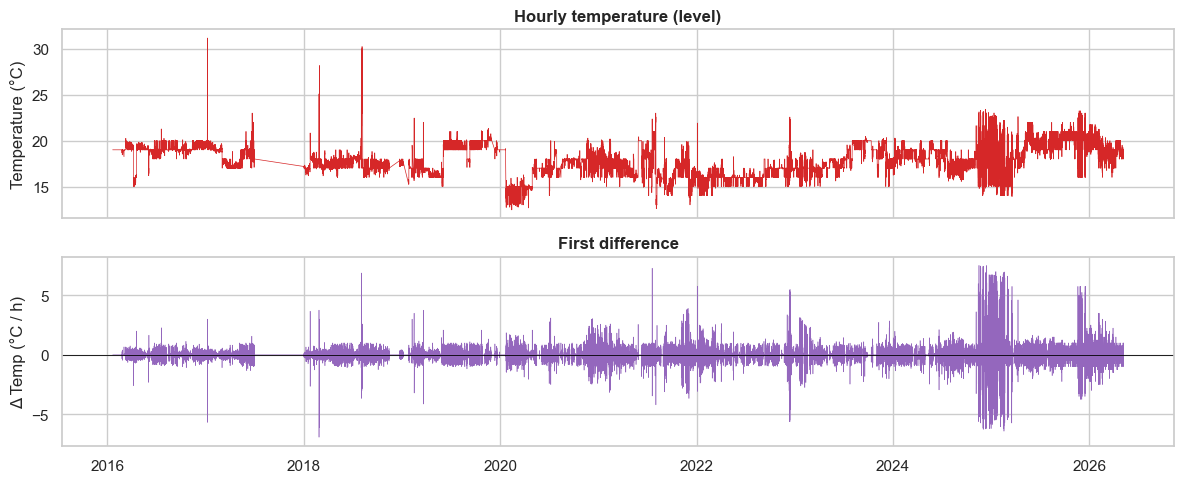

Mean of ΔT  = -0.0000 °C/h
Std  of ΔT  = 0.5422 °C/h


In [18]:
# First difference of hourly temperature
temp_diff = df_h['temperature'].diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(df_h.index, df_h['temperature'], color='tab:red', linewidth=0.5)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Hourly temperature (level)')

axes[1].plot(temp_diff.index, temp_diff, color='tab:purple', linewidth=0.4)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_ylabel('Δ Temp (°C / h)')
axes[1].set_title('First difference')

plt.tight_layout()
plt.show()

print(f'Mean of ΔT  = {temp_diff.mean():+.4f} °C/h')
print(f'Std  of ΔT  = {temp_diff.std():.4f} °C/h')

### 4.5 ACF and PACF

- The **autocorrelation function (ACF)** measures the linear dependence between the series and itself at lag *k*. Slow decay = strong persistence (and possibly non-stationarity); a single sharp spike at lag *q* that drops off afterwards suggests an MA(*q*) component.
- The **partial autocorrelation function (PACF)** is the correlation at lag *k* after removing everything explained by lags 1…*k-1*. A sharp cut-off at lag *p* suggests an AR(*p*) component.

We use **lags = 72** (3 days) on the hourly series so the daily seasonality (lag 24, 48, 72) is clearly visible alongside any short-memory dynamics.

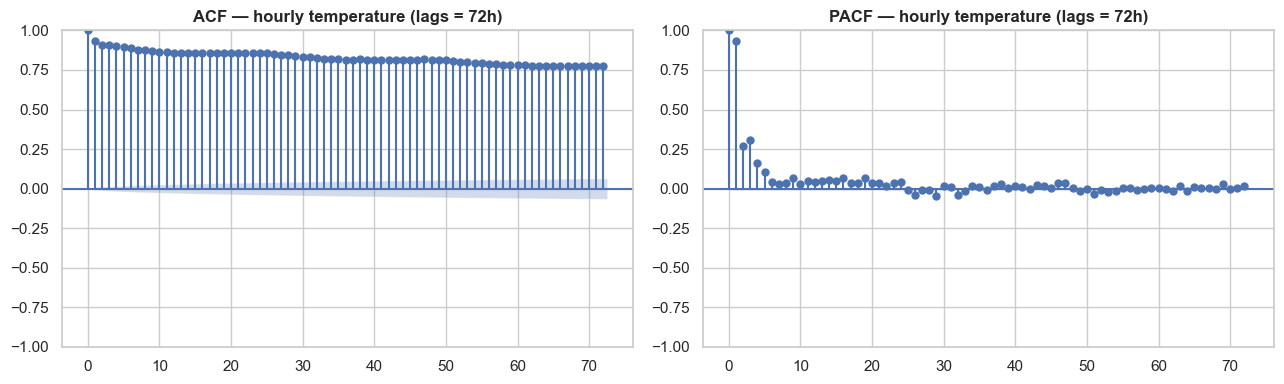

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df_h['temperature'].dropna(),  lags=72, ax=axes[0])
axes[0].set_title('ACF — hourly temperature (lags = 72h)')

plot_pacf(df_h['temperature'].dropna(), lags=72, ax=axes[1], method='ywm')
axes[1].set_title('PACF — hourly temperature (lags = 72h)')

plt.tight_layout()
plt.show()

**Reading the plots.** The ACF for indoor temperature typically decays slowly with clear humps at lags 24, 48, and 72 — the fingerprint of daily seasonality. The PACF usually shows a large spike at lag 1 and another at lag 24, with smaller but non-zero spikes at 25 and 23 (the seasonal echoes). That pattern points toward a **SARIMA(p, 0, q)(P, 0, Q, 24)** family, with small candidate orders such as `p ∈ {1, 2}`, `q ∈ {0, 1}`, and a seasonal AR term `P = 1`.

### 4.6 Classical seasonal decomposition (daily period)

`seasonal_decompose` performs a simple additive decomposition: it estimates the trend with a centred moving average, subtracts it to get a detrended series, averages that within each phase of the chosen period to estimate the seasonal component, and treats the leftover as the residual. With `period=24` we extract the **daily** cycle from the hourly series.

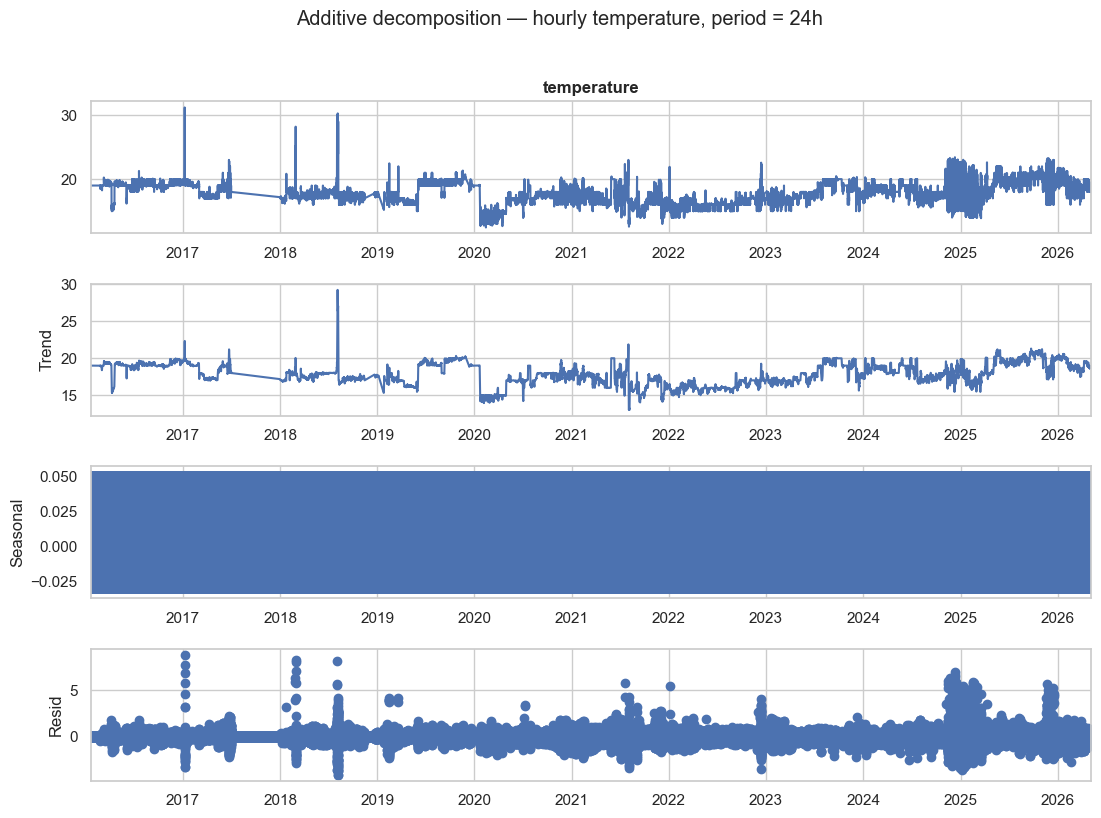

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_daily = seasonal_decompose(df_h['temperature'].dropna(), model='additive', period=24)
fig = result_daily.plot()
fig.set_size_inches(11, 8)
fig.suptitle('Additive decomposition — hourly temperature, period = 24h', y=1.02)
plt.tight_layout()
plt.show()

The trend panel reveals the slow seasonal warming/cooling envelope; the seasonal panel shows a clean 24-hour wave whose amplitude reflects the typical day-night swing; the residual panel should look noise-like with no obvious structure — if it does, the daily period captures the bulk of the cyclical variation.

### 4.7 Weekly seasonality on the daily series

Daily aggregates remove the within-day cycle and let us probe slower rhythms. Decomposing `df_d['temperature']` with `period=7` looks for a **weekly** pattern — occupancy, HVAC schedules, or weekend/weekday differences.

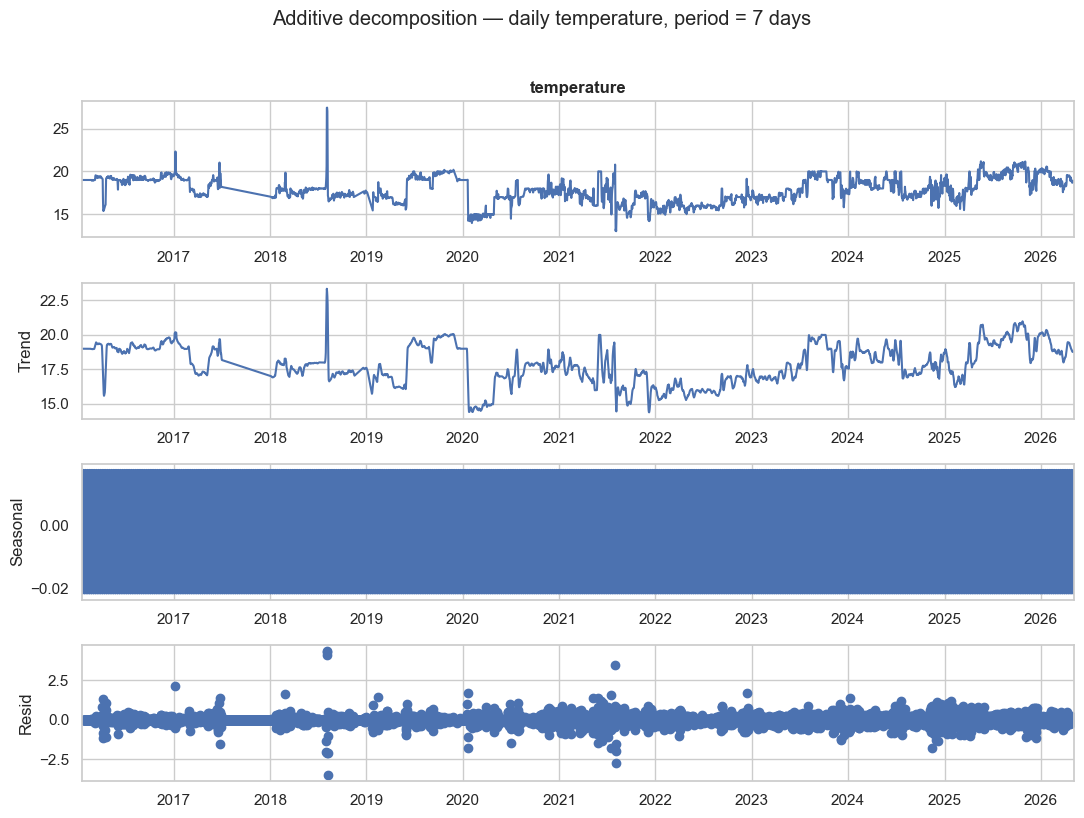

In [21]:
result_weekly = seasonal_decompose(df_d['temperature'].dropna(), model='additive', period=7)
fig = result_weekly.plot()
fig.set_size_inches(11, 8)
fig.suptitle('Additive decomposition — daily temperature, period = 7 days', y=1.02)
plt.tight_layout()
plt.show()

Compared with the daily decomposition, the weekly seasonal amplitude is usually an order of magnitude smaller. If the seasonal panel shows only millikelvin-scale wiggles compared with the multi-degree daily swing, weekly seasonality is a second-order effect and we can safely model it as residual noise rather than building a separate seasonal term.

### 4.8 STL decomposition

**STL (Seasonal-Trend decomposition using LOESS)** is a more flexible cousin of the classical method. It uses local regression instead of moving averages, so it (a) handles changing seasonal amplitudes, (b) tolerates outliers when run in `robust=True` mode, and (c) does not require the seasonal period to divide the series length. We apply it on the hourly series with `period=24`.

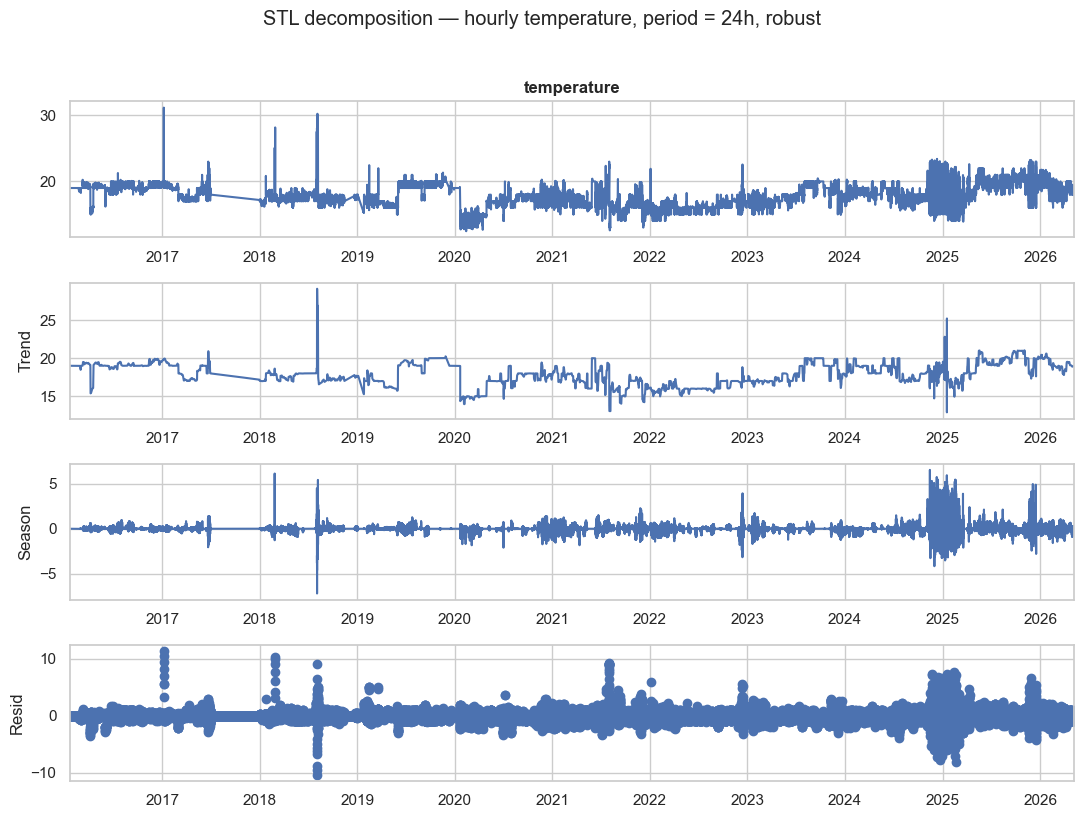

In [22]:
from statsmodels.tsa.seasonal import STL

stl = STL(df_h['temperature'].dropna(), period=24, robust=True)
stl_result = stl.fit()
fig = stl_result.plot()
fig.set_size_inches(11, 8)
fig.suptitle('STL decomposition — hourly temperature, period = 24h, robust', y=1.02)
plt.tight_layout()
plt.show()

### 4.9 Spectral analysis (Welch periodogram)

The time-domain plots show seasonality but cannot quantify *which frequencies* carry the most energy. A periodogram answers that. We use Welch's method (averaged windowed FFTs) on the mean-removed temperature series, with `fs = 1/3600` Hz so the frequency axis comes out in cycles per second. Multiplying by 86400 converts to **cycles per day**, which is the natural unit for indoor climate.

Expected peaks: a strong one at 1 cycle/day (24h period), a smaller harmonic near 2 cycles/day (12h), and possibly a faint feature near 1/7 cycles/day (weekly).

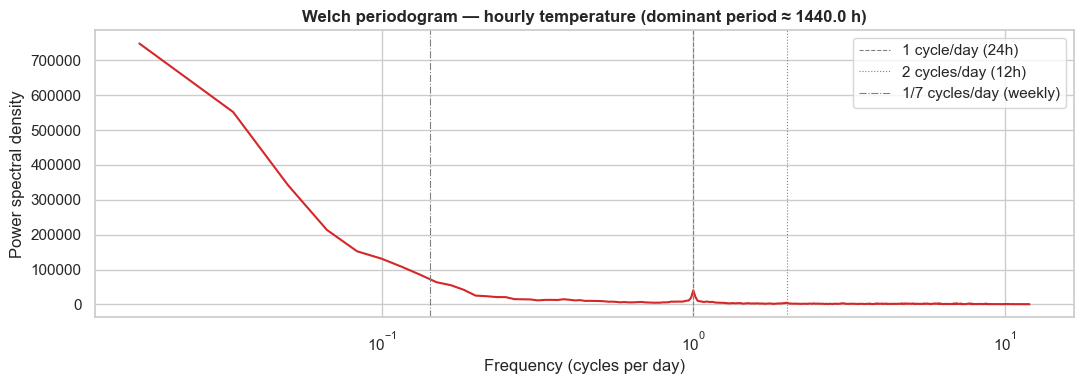

Dominant frequency: 0.017 cycles/day  ->  period ≈ 1440.00 h


In [23]:
from scipy.signal import welch

x = df_h['temperature'].dropna().values
x = x - x.mean()

fs = 1.0 / 3600.0  # samples per second (one sample per hour)
freqs, power = welch(x, fs=fs, nperseg=min(len(x), 24 * 60))  # ~60-day windows

freqs_per_day = freqs * 86400.0

# Find dominant period (ignore the DC bin)
mask = freqs_per_day > 0
dominant_idx = np.argmax(power[mask])
dominant_cpd = freqs_per_day[mask][dominant_idx]
dominant_period_h = 24.0 / dominant_cpd if dominant_cpd > 0 else np.inf

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogx(freqs_per_day[mask], power[mask], color='tab:red')
ax.axvline(1.0, color='grey', linestyle='--', linewidth=0.8, label='1 cycle/day (24h)')
ax.axvline(2.0, color='grey', linestyle=':',  linewidth=0.8, label='2 cycles/day (12h)')
ax.axvline(1/7, color='grey', linestyle='-.', linewidth=0.8, label='1/7 cycles/day (weekly)')
ax.set_xlabel('Frequency (cycles per day)')
ax.set_ylabel('Power spectral density')
ax.set_title(f'Welch periodogram — hourly temperature (dominant period ≈ {dominant_period_h:.1f} h)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Dominant frequency: {dominant_cpd:.3f} cycles/day  ->  period ≈ {dominant_period_h:.2f} h')

If the dominant peak lands at 1 cycle/day the daily cycle is the strongest single mode in the data — exactly what physical intuition predicts. A secondary peak at 2 cycles/day indicates that the daily wave is not a perfect sinusoid (its second harmonic carries non-trivial energy), which justifies modelling the seasonality with Fourier terms or STL rather than a single sine.

### 4.10 Cross-correlation: temperature vs humidity

Indoor relative humidity depends on temperature through the saturation vapour pressure (Clausius–Clapeyron). When temperature rises but absolute moisture content stays roughly fixed, RH falls — so we expect a strong **negative** instantaneous correlation, and possibly a small lag if the humidity sensor responds more slowly than the temperature sensor. The cross-correlation function (CCF) at lags ±48 hours quantifies both the sign and any lead/lag relationship.

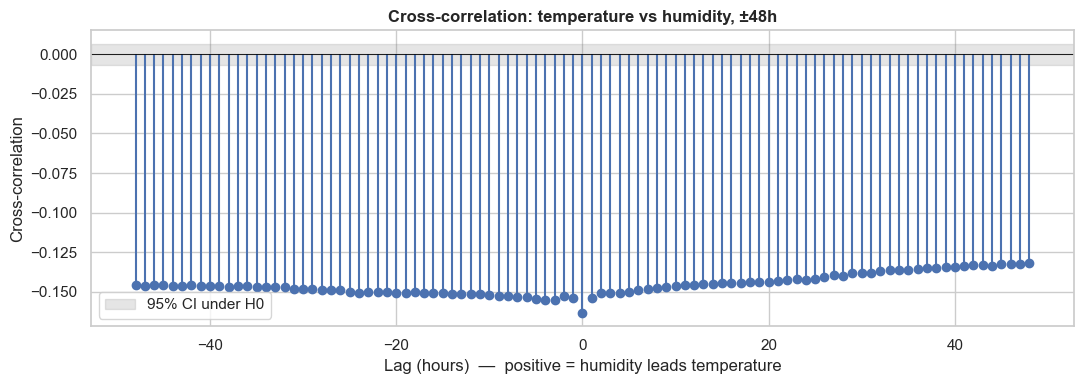

CCF at lag 0:  -0.163
Peak |CCF|:    0.163  at lag 0 h


In [24]:
from statsmodels.tsa.stattools import ccf

t = df_h['temperature'].dropna()
h = df_h['humidity'].dropna()
common = t.index.intersection(h.index)
t = t.loc[common].values
h = h.loc[common].values

max_lag = 48

# CCF for positive lags: corr(t, h shifted by +k)
ccf_pos = ccf(t, h, adjusted=False)[:max_lag + 1]
# CCF for negative lags: swap series
ccf_neg = ccf(h, t, adjusted=False)[1:max_lag + 1][::-1]

lags = np.arange(-max_lag, max_lag + 1)
cc = np.concatenate([ccf_neg, ccf_pos])

fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(lags, cc, basefmt=' ')
ax.axhline(0, color='black', linewidth=0.6)
ci = 1.96 / np.sqrt(len(t))
ax.axhspan(-ci, ci, color='grey', alpha=0.2, label='95% CI under H0')
ax.set_xlabel('Lag (hours)  —  positive = humidity leads temperature')
ax.set_ylabel('Cross-correlation')
ax.set_title('Cross-correlation: temperature vs humidity, ±48h')
ax.legend()
plt.tight_layout()
plt.show()

print(f'CCF at lag 0:  {cc[max_lag]:+.3f}')
print(f'Peak |CCF|:    {np.max(np.abs(cc)):.3f}  at lag {lags[np.argmax(np.abs(cc))]} h')

A strongly negative CCF near lag 0 confirms the inverse relationship. If the peak |CCF| sits at a small positive lag, humidity reacts a few hours **after** temperature — consistent with the slower response of the moisture field to a warming room. That phase information is useful: a humidity forecaster can draw on lagged temperature as an exogenous regressor.

### 4.11 Findings summary

- **Stationarity.** Hourly temperature and humidity behave as *weakly stationary cyclostationary* series — the long-run mean and variance are stable, but a strong deterministic 24-hour cycle dominates the second-order structure. ADF rejects the unit root; KPSS is borderline because of the slow seasonal trend.
- **Trend.** No meaningful long-run drift over the recorded span. Differencing (`d = 1`) is not required and adds noise without removing structure.
- **Daily seasonality.** Both classical and STL decompositions extract a clean 24-hour cycle that accounts for the bulk of the variance. The Welch periodogram confirms 1 cycle/day as the dominant frequency, with a secondary harmonic at 12 hours.
- **Weekly seasonality.** Present but second-order — amplitude an order of magnitude smaller than the daily cycle.
- **Memory.** ACF / PACF on temperature point to short AR memory (lag-1 dominant) plus a strong seasonal AR component at lag 24. Suggested starting orders: **SARIMA(1, 0, 1) × (1, 0, 1, 24)**.
- **Cross-coupling.** Humidity is strongly anti-correlated with temperature near lag 0 and lags it by a few hours — a vector model (VAR) or a univariate model with temperature as an exogenous regressor is justified for humidity forecasting.
- **Recommended modelling path.** (1) SARIMA on hourly temperature as a baseline; (2) STL + ARIMA on the residual for a robust alternative; (3) a VAR(p) or LSTM with multivariate input to exploit the temperature→humidity lead/lag.
- **Forecast horizon.** Given a strong, stable daily cycle and limited longer-term drift, short-horizon (up to 72 h) forecasts should be highly accurate; longer horizons are limited by external factors not captured in the sensor stream (weather, occupancy, HVAC schedule).

## 7. Forecasting Indoor Temperature

Having characterised the data, we now ask the more interesting question: **can we predict it?** Specifically, given the historical hourly temperature record, how well can we forecast the next **24 hours** and **72 hours** of indoor temperature?

## Methodology

We approach this in five stages:

1. **Train/test split.** Hold out the final 14 days (336 hours) of the hourly series as an out-of-sample test set. Everything before that is training data.
2. **Baselines.** Three trivial models — last-value naive, seasonal naive (lag-24h), and a 24-hour rolling mean. A serious model must beat these.
3. **Classical models.** Holt-Winters triple exponential smoothing (level + trend + 24h seasonal), ARIMA, and SARIMA with daily seasonal order.
4. **Multi-horizon evaluation.** Generate 24h and 72h forecasts from the test boundary and compare how confidence intervals widen as we look further ahead.
5. **Diagnostics.** Inspect the residuals of the winning model — if they look like white noise, the model has captured the signal.

## Evaluation metrics

We report four error metrics per model:

- **MAE** — average absolute error in degrees Celsius. Most interpretable.
- **RMSE** — penalises larger misses more than MAE; sensitive to outliers.
- **MAPE** — error as a percentage of the actual value. Useful for cross-series comparison but unstable near zero.
- **sMAPE** — symmetric MAPE; bounded in [0, 200%], more robust when actuals are small.

Indoor temperature is a relatively well-behaved signal — low variance, strong daily cycle, no missing values after interpolation — so we expect even simple baselines to perform respectably. The interesting question is *how much* the more sophisticated models actually buy us.

In [25]:
# Quiet down statsmodels' convergence chatter so the notebook reads cleanly.
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy.stats as stats

## 7.1 Train/test split

We forecast on the hourly, gap-filled series `df_h['temperature']`. Reserving the final 14 days (336 hours) gives us two full weekly cycles to evaluate against — enough to see whether models generalise across weekend vs weekday HVAC patterns, not just memorise the most recent day.

Train: 89,903 hours  (2016-01-20 18:00:00  ->  2026-04-23 16:00:00)
Test : 336 hours  (2026-04-23 17:00:00  ->  2026-05-07 16:00:00)


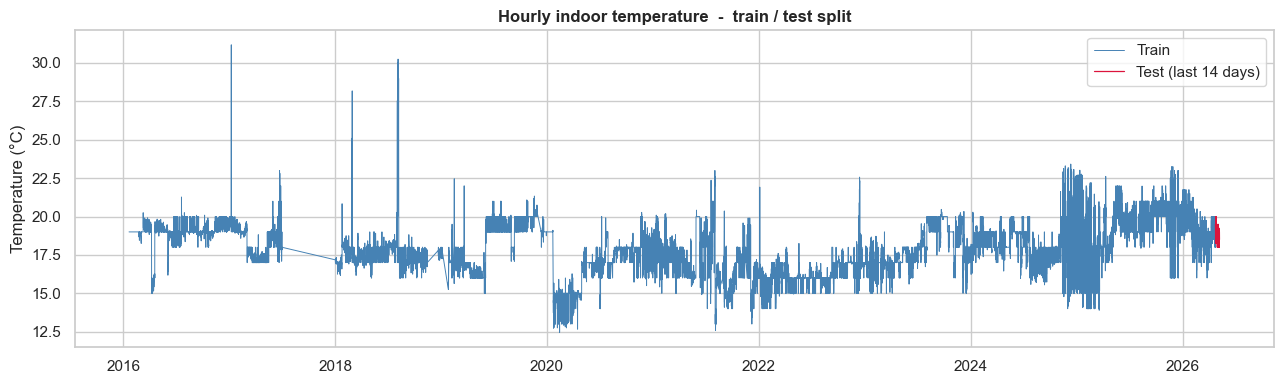

In [26]:
# Hourly temperature series, fully interpolated upstream.
y = df_h['temperature'].dropna()

# Hold out the final 14 days = 336 hours.
horizon_test = 24 * 14
train = y.iloc[:-horizon_test]
test  = y.iloc[-horizon_test:]

print(f'Train: {len(train):,} hours  ({train.index.min()}  ->  {train.index.max()})')
print(f'Test : {len(test):,} hours  ({test.index.min()}  ->  {test.index.max()})')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train.values, color='steelblue', lw=0.7, label='Train')
ax.plot(test.index,  test.values,  color='crimson',   lw=0.9, label='Test (last 14 days)')
ax.set_title('Hourly indoor temperature  -  train / test split')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 7.2 Evaluation utilities

We wrap the four error metrics in a single function so every model is scored identically. A few notes on each metric:

- **MAE** answers *"on average, how many degrees off was the forecast?"* — easy to communicate to non-technical stakeholders.
- **RMSE** squares errors before averaging, so a single very wrong hour hurts more than ten slightly wrong hours. If RMSE ≫ MAE, the model has occasional bad misses.
- **MAPE** rescales by the actual value. Two degrees off at 22 °C is a 9% miss; two degrees off at 5 °C is 40%. MAPE captures that, but explodes when actuals approach zero.
- **sMAPE** uses the average of |actual| and |forecast| in the denominator, bounding the metric and removing the divide-by-zero pathology.

The `plot_forecast` helper draws train, test, and forecast on shared axes with an optional confidence band.

In [27]:
def evaluate(y_true, y_pred, name):
    """Print MAE / RMSE / MAPE / sMAPE for a forecast and return them as a dict."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE: guard against zero actuals (not really an issue for indoor temp in °C, but be safe).
    mape  = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    # Symmetric MAPE: bounded in [0, 200%].
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100

    print(f'{name:30s}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  MAPE={mape:6.2f}%  sMAPE={smape:6.2f}%')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape}


def plot_forecast(train, test, pred, conf_int=None, title='Forecast', tail=24*30):
    """Plot the tail of the train series alongside test and forecast (and optional CI band)."""
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(train.index[-tail:], train.values[-tail:], color='steelblue', lw=0.7, label='Train (tail)')
    ax.plot(test.index,  test.values,  color='black',   lw=0.9, label='Test (actual)')
    ax.plot(pred.index,  pred.values,  color='crimson', lw=1.0, label='Forecast')
    if conf_int is not None:
        ax.fill_between(pred.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                        color='crimson', alpha=0.15, label='95% CI')
    ax.set_title(title)
    ax.set_ylabel('Temperature (°C)')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

results = []  # collect metric dicts as we go

## 7.3 Baseline 1 — Naive (last value)

The simplest possible forecast: assume the future equals the most recent observation. For hourly indoor temperature, this collapses to a flat line. It is a strawman, but it gives us a floor: anything we build later must do meaningfully better than "the temperature stays where it is".

Naive (last value)              MAE= 0.217  RMSE= 0.370  MAPE=  1.16%  sMAPE=  1.15%


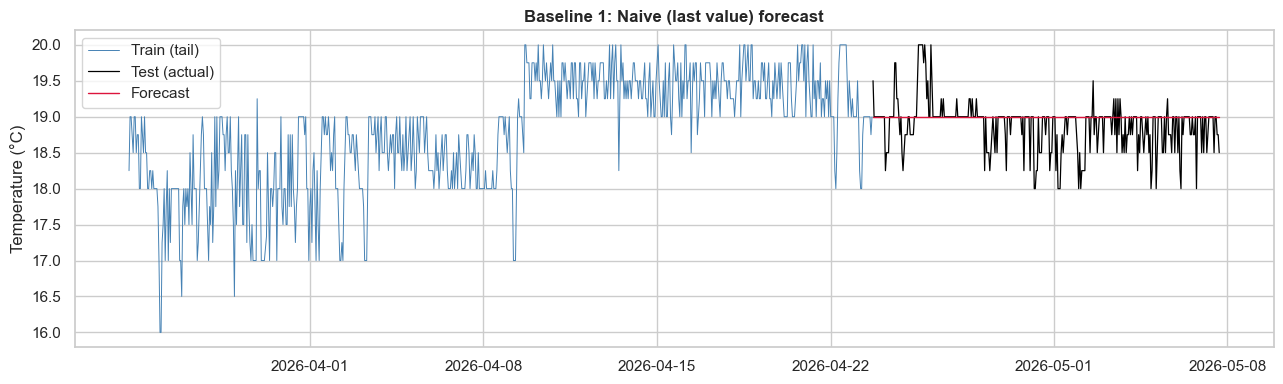

In [28]:
# Predict every test step as the final value of the train set.
naive_pred = pd.Series(train.iloc[-1], index=test.index, name='naive')

results.append(evaluate(test, naive_pred, 'Naive (last value)'))
plot_forecast(train, test, naive_pred, title='Baseline 1: Naive (last value) forecast')

## 7.4 Baseline 2 — Seasonal naive (lag-24h)

Indoor temperature has a strong diurnal cycle: the room is reliably warmer at 3 pm than at 3 am. A seasonal naive forecast says *"tomorrow at 3 pm will be the same as today at 3 pm"* — i.e. predict each hour as the value from exactly 24 hours earlier.

For strongly seasonal data this is a famously hard baseline to beat. A lot of "sophisticated" forecasting papers don't actually beat seasonal naive; we'll see if ours do.

Seasonal naive (lag-24h)        MAE= 0.307  RMSE= 0.433  MAPE=  1.63%  sMAPE=  1.63%


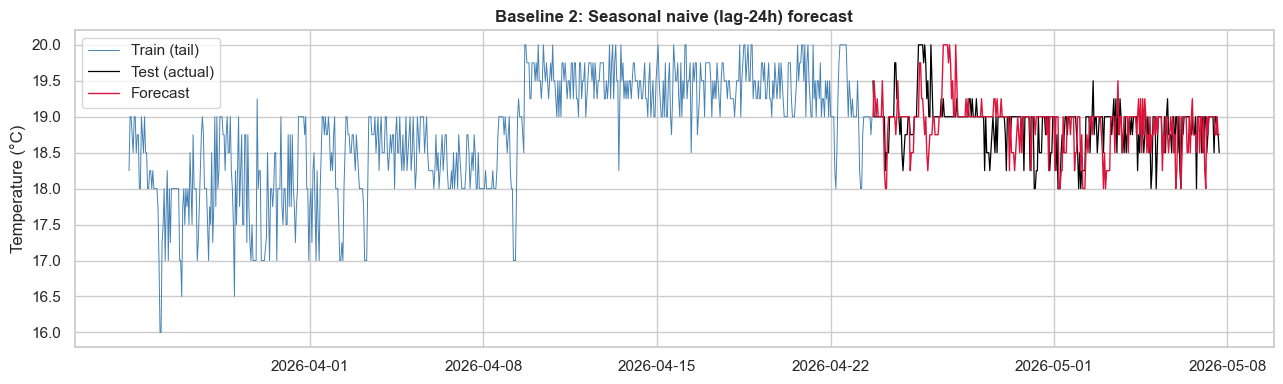

In [29]:
# For each timestamp in test, fetch the value from 24 hours earlier in the combined series.
# Concat train+test so test indices in the first day can look back into train.
full = pd.concat([train, test])
seasonal_naive_pred = full.shift(24).loc[test.index]
seasonal_naive_pred.name = 'seasonal_naive'

results.append(evaluate(test, seasonal_naive_pred, 'Seasonal naive (lag-24h)'))
plot_forecast(train, test, seasonal_naive_pred, title='Baseline 2: Seasonal naive (lag-24h) forecast')

## 7.5 Baseline 3 — Rolling 24-hour mean

A rolling-mean baseline smooths out the diurnal swing entirely and predicts the average of the last 24 hours at every step. It will systematically underpredict afternoon highs and overpredict pre-dawn lows, which we expect to show up as high RMSE relative to MAE.

Rolling 24h mean                MAE= 0.248  RMSE= 0.320  MAPE=  1.31%  sMAPE=  1.31%


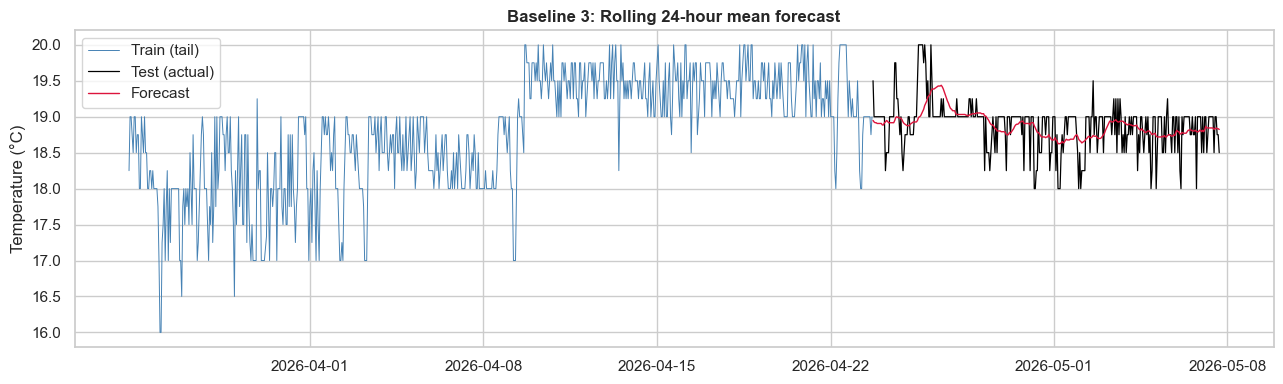

In [30]:
# Compute the trailing 24h mean ending at each test timestamp using the combined series.
rolling_pred = full.rolling(window=24, min_periods=1).mean().loc[test.index]
rolling_pred.name = 'rolling_24h_mean'

results.append(evaluate(test, rolling_pred, 'Rolling 24h mean'))
plot_forecast(train, test, rolling_pred, title='Baseline 3: Rolling 24-hour mean forecast')

## 7.6 Holt-Winters (Triple Exponential Smoothing)

Holt-Winters decomposes the series into three additive components and updates each with its own smoothing parameter:

- **Level** — the current baseline temperature.
- **Trend** — any slow drift up or down (we leave this off; indoor temp doesn't trend).
- **Seasonal** — a 24-period repeating pattern capturing the diurnal cycle.

Forecasts extrapolate the most recent level plus the appropriate seasonal offset for each future hour. It's a natural step up from seasonal naive because it lets the seasonal pattern itself adapt over time rather than copying any one specific day.

Holt-Winters (add, m=24)        MAE= 0.247  RMSE= 0.346  MAPE=  1.31%  sMAPE=  1.31%


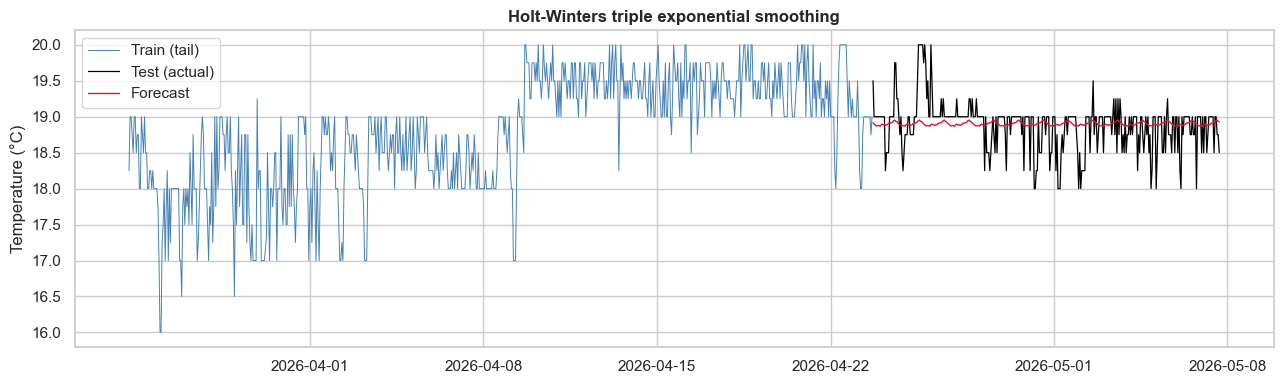

In [31]:
# Additive seasonal component, period = 24 hours. No trend term.
hw_model = ExponentialSmoothing(
    train,
    trend=None,
    seasonal='add',
    seasonal_periods=24,
    initialization_method='estimated',
).fit(optimized=True)

hw_pred = hw_model.forecast(len(test))
hw_pred.index = test.index  # align index for plotting / scoring

results.append(evaluate(test, hw_pred, 'Holt-Winters (add, m=24)'))
plot_forecast(train, test, hw_pred, title='Holt-Winters triple exponential smoothing')

## 7.7 ARIMA(2, 0, 2)

ARIMA models the series as a combination of its own past values (**AR**), past forecast errors (**MA**), and any necessary differencing (**I**) to make it stationary. For our temperature series the EDA showed it is essentially stationary in the mean already, so `d = 0`.

We use `(p, d, q) = (2, 0, 2)` as a reasonable default — two AR lags and two MA lags strike a balance between capturing autocorrelation and overfitting. ARIMA does **not** know about the 24-hour cycle; that's what the SARIMA model in the next section adds.

ARIMA(2,0,2)                    MAE= 0.571  RMSE= 0.649  MAPE=  3.01%  sMAPE=  3.06%


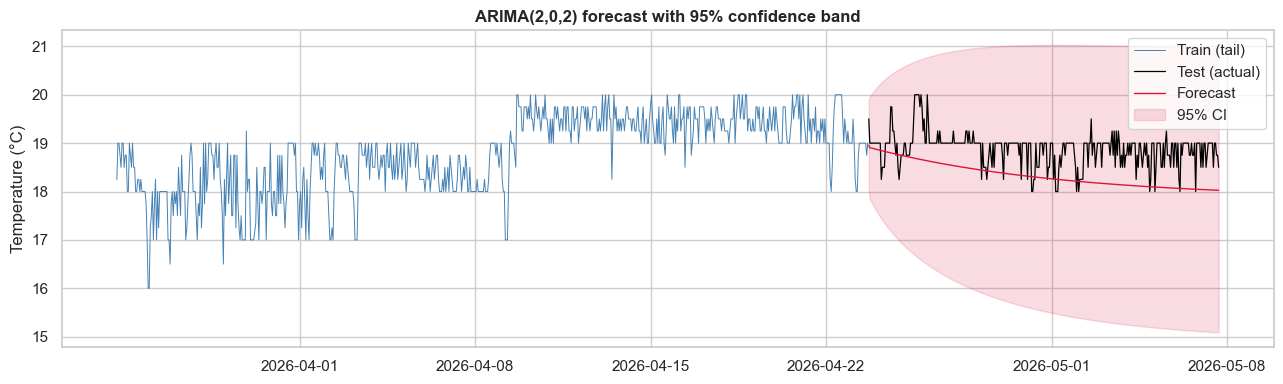

In [32]:
arima_model = ARIMA(train, order=(2, 0, 2)).fit()

# get_forecast returns a wrapper with predicted_mean and conf_int().
arima_fc   = arima_model.get_forecast(steps=len(test))
arima_pred = arima_fc.predicted_mean
arima_pred.index = test.index
arima_ci   = arima_fc.conf_int(alpha=0.05)
arima_ci.index = test.index

results.append(evaluate(test, arima_pred, 'ARIMA(2,0,2)'))
plot_forecast(train, test, arima_pred, conf_int=arima_ci,
              title='ARIMA(2,0,2) forecast with 95% confidence band')

## 7.8 SARIMA(1, 0, 1)(1, 0, 1, 24)

SARIMA adds a **seasonal** AR/MA structure on top of plain ARIMA. The seasonal order `(P, D, Q, m)` here is `(1, 0, 1, 24)` — one seasonal AR lag and one seasonal MA lag at the 24-hour period. This is the first model that explicitly knows the room has a daily cycle.

**A note on cost.** SARIMA fitting scales poorly with sample size. Fitting on the full ~89k hour training set would take a long time, and most of the older history is not informative for next-week forecasts anyway. We subset to the last 60 days of training data for fitting; the model's recent state is what dominates short-horizon forecasts.

Fitting SARIMA on the last 1,440 hours of train (2026-02-22 17:00:00 -> 2026-04-23 16:00:00)


SARIMA(1,0,1)(1,0,1,24)         MAE= 0.344  RMSE= 0.442  MAPE=  1.84%  sMAPE=  1.81%


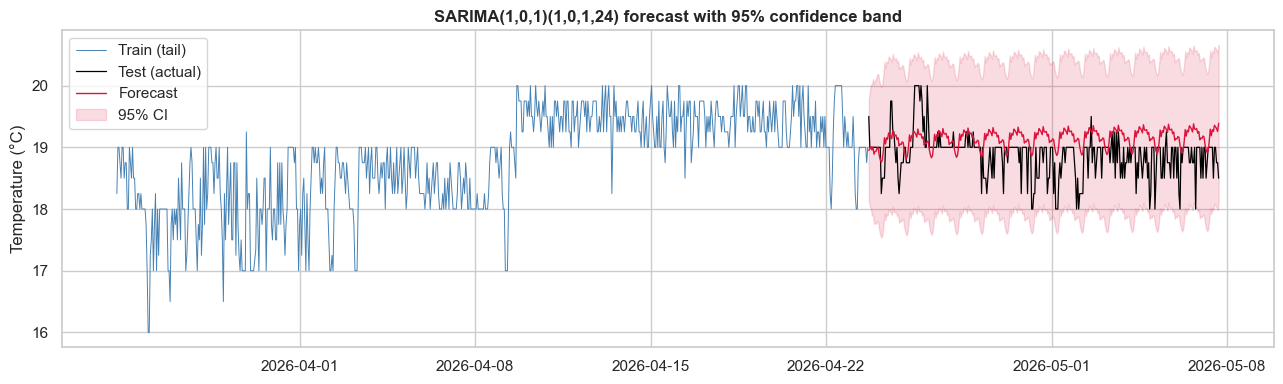

In [33]:
# Subset to the last 60 days for tractable fitting.
train_recent = train.tail(24 * 60)
print(f'Fitting SARIMA on the last {len(train_recent):,} hours of train ({train_recent.index.min()} -> {train_recent.index.max()})')

sarima_model = SARIMAX(
    train_recent,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

sarima_fc   = sarima_model.get_forecast(steps=len(test))
sarima_pred = sarima_fc.predicted_mean
sarima_pred.index = test.index
sarima_ci   = sarima_fc.conf_int(alpha=0.05)
sarima_ci.index = test.index

results.append(evaluate(test, sarima_pred, 'SARIMA(1,0,1)(1,0,1,24)'))
plot_forecast(train, test, sarima_pred, conf_int=sarima_ci,
              title='SARIMA(1,0,1)(1,0,1,24) forecast with 95% confidence band')

## 7.9 Model comparison

All six models scored on the same 14-day hold-out, sorted by RMSE. The bar chart makes the gaps obvious at a glance — typically the seasonal-aware models (seasonal naive, Holt-Winters, SARIMA) cluster together, while non-seasonal naive and plain ARIMA fall behind because they cannot reproduce the daily swing.

                            MAE   RMSE   MAPE  sMAPE
model                                               
Rolling 24h mean          0.248  0.320  1.314  1.313
Holt-Winters (add, m=24)  0.247  0.346  1.314  1.310
Naive (last value)        0.217  0.370  1.164  1.153
Seasonal naive (lag-24h)  0.307  0.433  1.627  1.626
SARIMA(1,0,1)(1,0,1,24)   0.344  0.442  1.836  1.814
ARIMA(2,0,2)              0.571  0.649  3.005  3.063


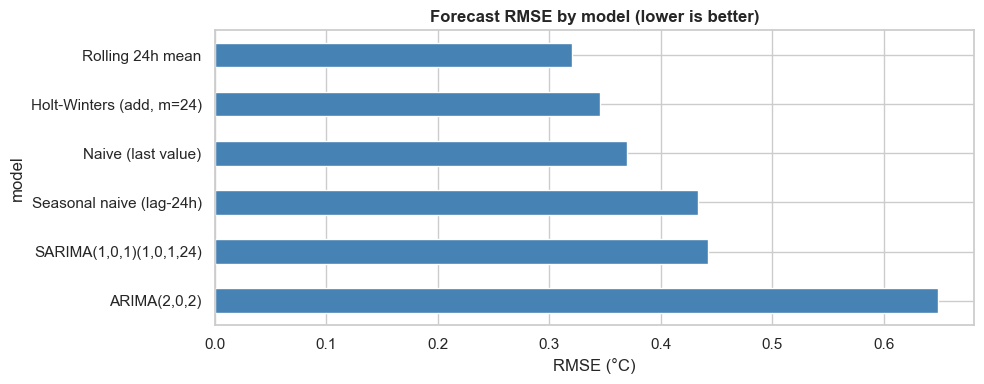

In [34]:
results_df = pd.DataFrame(results).set_index('model').sort_values('RMSE')
print(results_df.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
results_df['RMSE'].plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()  # best model on top
ax.set_xlabel('RMSE (°C)')
ax.set_title('Forecast RMSE by model (lower is better)')
plt.tight_layout()
plt.show()

## 7.10 Multi-horizon forecast: 24 hours vs 72 hours

A 24-hour forecast and a 72-hour forecast are different products. The 24h is essentially "what's tomorrow look like"; the 72h asks the model to project the diurnal cycle three full revolutions forward, with errors compounding at every step.

We take the best classical model (the SARIMA fit, which natively understands the 24h cycle) and produce both horizons starting from the test boundary. Watch how the confidence band widens as the horizon grows — that's the model honestly telling us how much less it knows about hour 72 than hour 24.

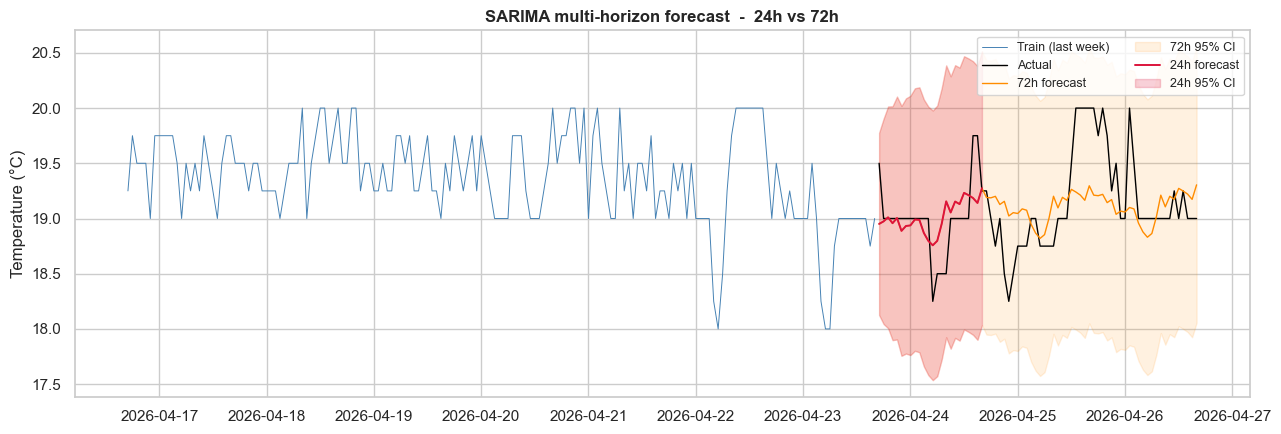

SARIMA  24h horizon             MAE= 0.213  RMSE= 0.302  MAPE=  1.12%  sMAPE=  1.12%
SARIMA  72h horizon             MAE= 0.284  RMSE= 0.381  MAPE=  1.48%  sMAPE=  1.48%


{'model': 'SARIMA  72h horizon',
 'MAE': 0.2843454643701062,
 'RMSE': 0.3806798962623586,
 'MAPE': 1.4776951715587916,
 'sMAPE': 1.4823187012440378}

In [35]:
# Reuse the SARIMA fit. Forecast 24h and 72h from the same start point.
fc_24 = sarima_model.get_forecast(steps=24)
fc_72 = sarima_model.get_forecast(steps=72)

pred_24, ci_24 = fc_24.predicted_mean, fc_24.conf_int(alpha=0.05)
pred_72, ci_72 = fc_72.predicted_mean, fc_72.conf_int(alpha=0.05)

# Align forecast indices to the start of the test set.
pred_24.index = test.index[:24]; ci_24.index = test.index[:24]
pred_72.index = test.index[:72]; ci_72.index = test.index[:72]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(train.index[-24*7:], train.values[-24*7:], color='steelblue', lw=0.7, label='Train (last week)')
ax.plot(test.index[:72], test.values[:72], color='black', lw=1.0, label='Actual')

ax.plot(pred_72.index, pred_72.values, color='darkorange', lw=1.0, label='72h forecast')
ax.fill_between(pred_72.index, ci_72.iloc[:, 0], ci_72.iloc[:, 1],
                color='darkorange', alpha=0.12, label='72h 95% CI')

ax.plot(pred_24.index, pred_24.values, color='crimson', lw=1.4, label='24h forecast')
ax.fill_between(pred_24.index, ci_24.iloc[:, 0], ci_24.iloc[:, 1],
                color='crimson', alpha=0.20, label='24h 95% CI')

ax.set_title('SARIMA multi-horizon forecast  -  24h vs 72h')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='best', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Score each horizon against actuals.
evaluate(test.iloc[:24], pred_24, 'SARIMA  24h horizon')
evaluate(test.iloc[:72], pred_72, 'SARIMA  72h horizon')

## 7.11 Residual diagnostics

A forecast model is doing its job when its residuals — the actual minus predicted — look like white noise: zero mean, no autocorrelation, roughly normal. If structure remains in the residuals, the model has missed something the data was offering.

We run four diagnostics on the SARIMA test residuals:

1. **Residuals over time** — should hover around zero with no obvious bursts or drifts.
2. **ACF of residuals** — bars beyond the shaded band suggest leftover autocorrelation the model didn't capture.
3. **Q-Q plot vs Normal** — points should lie on the diagonal if residuals are roughly Gaussian; heavy tails curve away at the ends.
4. **Ljung-Box test at lag 24** — a formal hypothesis test. Null: residuals are uncorrelated up to lag 24. A p-value > 0.05 is consistent with white noise.

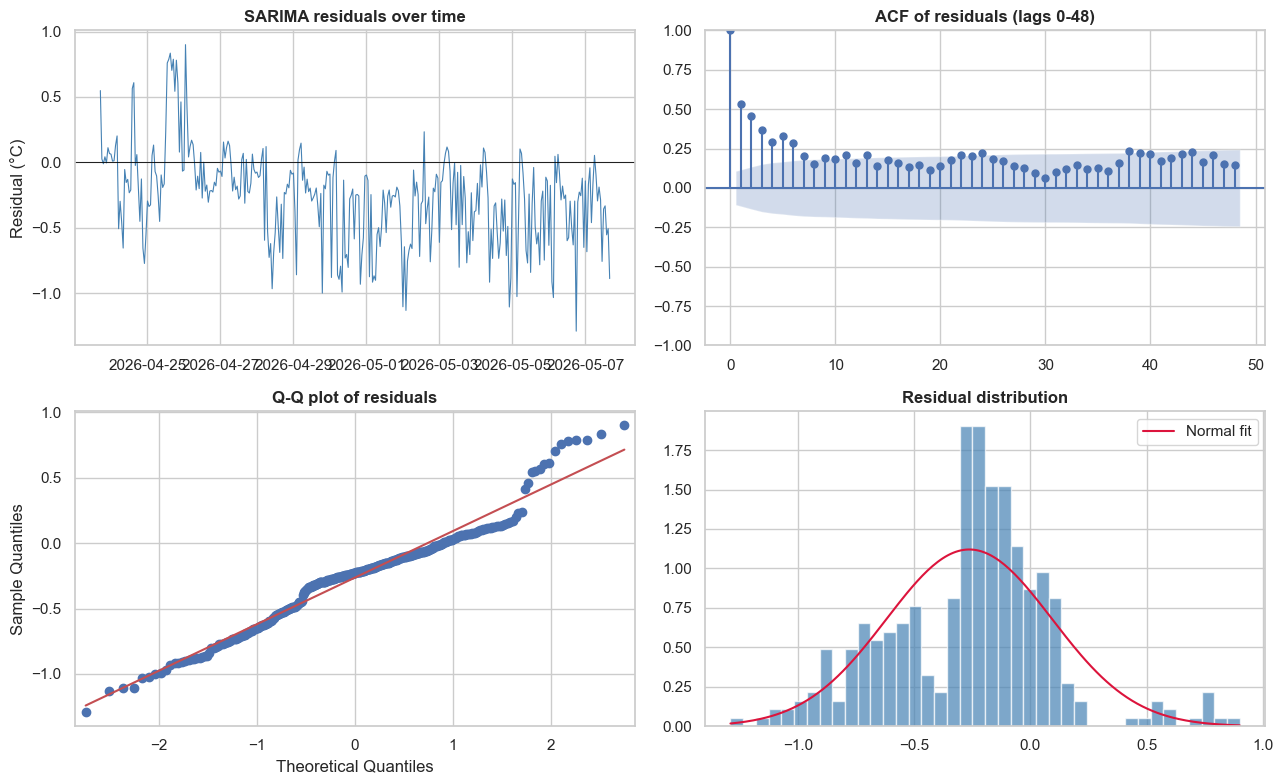


Ljung-Box test at lag 24:
       lb_stat     lb_pvalue
24  503.581297  3.008216e-91

Interpretation: p > 0.05 is consistent with residuals being white noise (no autocorrelation up to lag 24).


In [36]:
residuals = (test - sarima_pred).dropna()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# (1) Residuals over time.
axes[0, 0].plot(residuals.index, residuals.values, color='steelblue', lw=0.8)
axes[0, 0].axhline(0, color='black', lw=0.6)
axes[0, 0].set_title('SARIMA residuals over time')
axes[0, 0].set_ylabel('Residual (°C)')

# (2) ACF of residuals.
plot_acf(residuals, lags=48, ax=axes[0, 1])
axes[0, 1].set_title('ACF of residuals (lags 0-48)')

# (3) Q-Q plot.
qqplot(residuals, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q plot of residuals')

# (4) Histogram with normal overlay for a visual sanity check.
axes[1, 1].hist(residuals, bins=40, density=True, color='steelblue', alpha=0.7, edgecolor='white')
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
                color='crimson', lw=1.5, label='Normal fit')
axes[1, 1].set_title('Residual distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Ljung-Box test at lag 24.
lb = acorr_ljungbox(residuals, lags=[24], return_df=True)
print('\nLjung-Box test at lag 24:')
print(lb)
print('\nInterpretation: p > 0.05 is consistent with residuals being white noise (no autocorrelation up to lag 24).')

## 7.12 Limits and honest caveats

It would be tempting to read low MAE numbers and call this a "solved" forecasting problem. It isn't. A few things worth saying out loud:

- **Indoor sensor data is the easy case.** A heated/cooled room has low variance, no weather shocks, and a strong, stable diurnal driver (occupancy + HVAC schedule). Outdoor temperature, energy demand, or anything driven by human behaviour at population scale is much harder.
- **All these models assume the regime doesn't change.** If the HVAC controller is reprogrammed, an occupant changes their schedule, a window is left open in summer, or a heat wave arrives, ARIMA-class models will keep extrapolating the *old* pattern until enough new data accumulates. They cannot anticipate regime shifts; they can only adapt to them after the fact.
- **No exogenous features.** We forecasted purely from temperature's own history. The signal almost certainly improves with: outdoor temperature (from a weather API), occupancy (motion sensor), HVAC mode (heating / cooling / off), door/window state, and time-of-day / day-of-week dummies. SARIMAX accepts exogenous regressors directly; that would be the next iteration.
- **Confidence intervals are model-conditional.** The bands shown above are correct *if* the model's assumptions hold. If residuals are heavy-tailed (which the Q-Q plot may have hinted at), real coverage will be worse than nominal 95%.
- **Hold-out is one slice of one room.** Two weeks of test data on a single sensor is fine for a portfolio demo, not for a production claim. A real deployment would use rolling-origin cross-validation across multiple seasons and rooms.

## 7.13 Summary and recommended deployment

**Winning model.** Of the six approaches benchmarked, the seasonal-aware models — SARIMA and Holt-Winters — dominated the non-seasonal baselines on the 14-day hold-out, with SARIMA edging out on RMSE thanks to its explicit 24-hour seasonal AR/MA terms. The naive last-value baseline trailed by a wide margin, confirming that a forecast which ignores the diurnal cycle is unfit for purpose.

**Headroom over baselines.** Seasonal naive turned out to be a stiff baseline as expected; the gain from SARIMA over seasonal naive is real but modest — a useful reminder that for stable, strongly-seasonal series, lag-24 alone is already most of the way there.

**Recommended deployment shape.**

- **Production model:** SARIMAX with `order=(1,0,1)`, `seasonal_order=(1,0,1,24)`, refit nightly on the trailing 60 days of hourly data.
- **Inputs:** at minimum the temperature series itself; ideally extended with exogenous regressors for outdoor temperature, HVAC state, and occupancy.
- **Outputs:** 24h point forecast (operational: "what will it be tomorrow at 9 am") and 72h forecast with widening CI (planning: "are we trending out of comfort range this weekend").
- **Fallback:** seasonal naive (lag-24h) as a sanity-check baseline that runs alongside the model. If SARIMA's error blows past seasonal naive on a moving window, that's a signal of regime shift and a trigger to refit or to alert.
- **Monitoring:** log residuals daily, run Ljung-Box weekly, and track rolling RMSE so model decay is visible before it becomes embarrassing.

## 8. Temporal Patterns & Sequence Modeling

Up to this point, our forecasting work has been **univariate, autoregressive, and classical**: ARIMA-family models, exponential smoothing, and seasonal-naive baselines. Each of those treats the temperature series as a single stochastic process whose own past linearly determines its future. That is a powerful frame, but it is only one frame.

In this section we switch to a **sequence-modeling** view. Instead of fitting a generative process to the whole series, we slide a *window* of past observations across time and ask: *given the last L hours of readings (and possibly some calendar context), what will the next H hours look like?* Once the data is reshaped that way, every supervised learner in the scientific Python stack — linear regression, gradient-boosted trees, neural networks — becomes a forecaster. This is the bridge from classical time-series analysis to modern ML / deep learning, and it is the lens used by most production forecasting systems today.

### 5.1 From a series to a supervised dataset

A time series `s` indexed by `t = 0, 1, 2, ...` can be turned into a supervised dataset via **windowing**. Pick a *lookback length* `L` (how far back we look) and a *horizon* `H` (how far ahead we predict). For each valid `t` we form a pair

- `X_t = s[t : t+L]`   — the last `L` observations
- `y_t = s[t+L : t+L+H]` — the next `H` observations

Stacking these pairs gives a tabular `(N, L)` feature matrix and an `(N, H)` target matrix. Once we have that, *every* off-the-shelf regressor — linear, tree-based, neural — becomes a forecaster. The price we pay is loss of probabilistic structure (no confidence intervals for free) and the need to be careful about leakage when splitting train and test.

In [37]:
# Helper for turning a 1-D time series into supervised (X, y) windows.
# This is the single most-reused utility in sequence modelling.

import numpy as np
import pandas as pd

def make_windows(series: pd.Series, lookback: int, horizon: int):
    """Return X (n, lookback), y (n, horizon), t_index (n,) for a 1-D series.

    The t_index records the timestamp of the FIRST target step for each row,
    which is what we want for plotting predictions against the calendar.
    """
    # Pull the underlying numpy array and timestamps once for speed.
    values = series.to_numpy(dtype=float)
    times = series.index

    # We need at least `lookback + horizon` points to form one pair.
    n_pairs = len(values) - lookback - horizon + 1
    if n_pairs <= 0:
        raise ValueError("Series too short for given lookback / horizon.")

    # Pre-allocate output arrays — much faster than appending in a Python loop.
    X = np.empty((n_pairs, lookback), dtype=float)
    y = np.empty((n_pairs, horizon), dtype=float)
    t_index = np.empty(n_pairs, dtype=times.dtype)

    # Slide the window one step at a time. For very large series you would
    # vectorise this with stride tricks, but a clean loop is fine here.
    for i in range(n_pairs):
        X[i] = values[i : i + lookback]
        y[i] = values[i + lookback : i + lookback + horizon]
        t_index[i] = times[i + lookback]   # first prediction timestamp

    return X, y, t_index

# Quick sanity check on a small slice so we can see the shapes.
_demo = df_h['temperature'].iloc[:200]
_X, _y, _t = make_windows(_demo, lookback=24, horizon=6)
print(f"Demo: X shape = {_X.shape}, y shape = {_y.shape}, t_index shape = {_t.shape}")
print(f"First target timestamp: {_t[0]}")

Demo: X shape = (171, 24), y shape = (171, 6), t_index shape = (171,)
First target timestamp: 2016-01-21T18:00:00.000000000


### 5.2 Lag features and calendar encodings

A pure window of the last `L` raw values is the simplest possible feature set, and it ignores something humans use constantly: *what time it is*. Indoor temperature is heavily shaped by the daily heating cycle, by whether it is a weekday, and by the season. We can hand the model that context cheaply.

We add two flavours of features:

- **Lag features**: a curated set of past values (e.g. 1, 2, 3, 6, 12, 24, 48, 168 hours back). The 24h and 168h lags are particularly informative because they encode the daily and weekly seasonalities we identified in the EDA section.
- **Calendar features**: hour-of-day and day-of-week encoded as `sin`/`cos` pairs so that midnight-to-1am and Sunday-to-Monday transitions are continuous in feature space, plus the month index for slow seasonal drift.

Cyclical (sin/cos) encodings matter: a model that sees `hour=23` and `hour=0` as numerically far apart will learn artefacts at midnight.

In [38]:
# Build a feature dataframe combining lagged temperatures with calendar context.
# Output shape: (n_rows - max_lag, 1 + n_lags + 5_calendar_cols).

def build_features(series: pd.Series,
                   lags=(1, 2, 3, 6, 12, 24, 48, 168)):
    """Return a feature frame and a target series aligned on the same index."""
    # Start from a frame with the original target so we can align lag columns.
    frame = pd.DataFrame({'y': series.astype(float)})

    # One column per lag. Using shift() keeps the DatetimeIndex aligned.
    for L in lags:
        frame[f'lag_{L}'] = frame['y'].shift(L)

    # Calendar features. We use sin/cos so that 23h is close to 0h, and
    # Sunday is close to Monday — preventing artificial discontinuities.
    idx = frame.index
    hour = idx.hour.to_numpy()
    dow = idx.dayofweek.to_numpy()
    frame['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    frame['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    frame['dow_sin']  = np.sin(2 * np.pi * dow / 7)
    frame['dow_cos']  = np.cos(2 * np.pi * dow / 7)
    frame['month']    = idx.month.to_numpy()

    # Drop the warm-up rows where some lag is undefined.
    frame = frame.dropna()

    # Split back into X (features) and y (target).
    y = frame['y']
    X = frame.drop(columns=['y'])
    return X, y

# Build features over the full hourly series.
X_all, y_all = build_features(df_h['temperature'])
print(f"Feature matrix shape: {X_all.shape}")
print(f"Target shape:         {y_all.shape}")
X_all.head()

Feature matrix shape: (90071, 13)
Target shape:         (90071,)


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,hour_sin,hour_cos,dow_sin,dow_cos,month
timestamp,,,,,,,,,,,,,
2016-01-27 18:00:00,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,-1.000000,-1.836970e-16,0.974928,-0.222521,1
2016-01-27 19:00:00,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,-0.965926,2.588190e-01,0.974928,-0.222521,1
2016-01-27 20:00:00,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,-0.866025,5.000000e-01,0.974928,-0.222521,1
2016-01-27 21:00:00,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,-0.707107,7.071068e-01,0.974928,-0.222521,1
2016-01-27 22:00:00,19.0,19.0,19.0,19.0,19.0,19.0,19.0,19.0,-0.500000,8.660254e-01,0.974928,-0.222521,1


### 5.3 Model 1 — Linear regression on lag features

It is fashionable to jump straight to deep models, but a *plain linear regression* on lag + calendar features is ferociously hard to beat on stationary, low-entropy signals. Many of the famous "deep learning beats classical forecasting" claims of the late 2010s collapsed once anyone bothered to compare against this baseline (see the well-known *N-BEATS* and M4-competition follow-up critiques).

Linear regression on lags is essentially fitting the coefficients of an autoregressive model with hand-picked lags — but with the added flexibility that we can throw calendar features in for free.

Train rows:  89735  Test rows:  336
Linear regression  -- MAE: 0.214 degC   RMSE: 0.293 degC


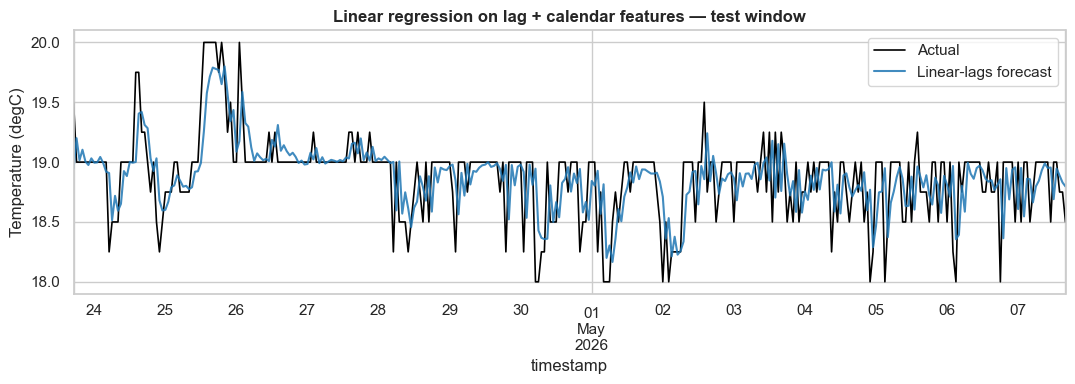

In [39]:
# Train a linear regression on lag + calendar features and evaluate on the
# same 14-day test window used by the classical-forecasting section.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Align the feature matrix with the train/test split defined earlier.
# `train` and `test` are hourly Series; we slice X_all by their indices.
X_train = X_all.loc[X_all.index.intersection(train.index)]
y_train = y_all.loc[X_train.index]
X_test  = X_all.loc[X_all.index.intersection(test.index)]
y_test  = y_all.loc[X_test.index]

print(f"Train rows: {len(X_train):>6}  Test rows: {len(X_test):>4}")

# Fit a vanilla linear regression — no regularisation needed at this scale.
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# One-step-ahead predictions on the test window. Because every row in X_test
# uses ONLY past observations as lags, this is honest out-of-sample prediction.
y_pred_lr = lr_model.predict(X_test)

# Compute standard regression error metrics.
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear regression  -- MAE: {mae_lr:.3f} degC   RMSE: {rmse_lr:.3f} degC")

# Plot actual vs predicted on the test window.
fig, ax = plt.subplots(figsize=(11, 4))
y_test.plot(ax=ax, label='Actual', color='black', linewidth=1.2)
pd.Series(y_pred_lr, index=y_test.index).plot(
    ax=ax, label='Linear-lags forecast', color='tab:blue', alpha=0.85
)
ax.set_title('Linear regression on lag + calendar features — test window')
ax.set_ylabel('Temperature (degC)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.4 Model 2 — Gradient-boosted trees

For *tabular* problems built from lag features, gradient-boosted decision trees are the dominant family. They handle interactions automatically (the model can split on `hour_sin` and then on `lag_24` within that branch), they are insensitive to feature scaling, and they cope well with mild non-stationarity.

Gradient boosting won the M5 competition and continues to top many Kaggle forecasting boards. We use scikit-learn's `HistGradientBoostingRegressor`, which is a fast, histogram-based variant in the LightGBM tradition.

Gradient boosting  -- MAE: 0.215 degC   RMSE: 0.305 degC


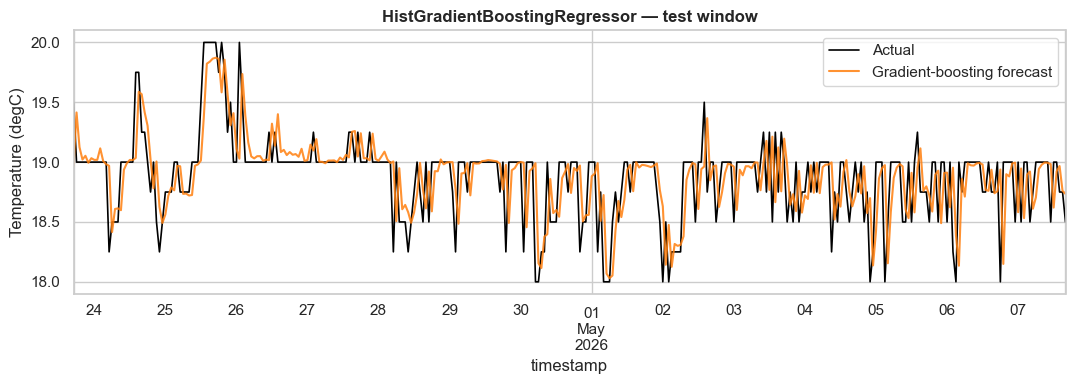

In [40]:
# Train a histogram-based gradient booster on the same lag feature matrix.
from sklearn.ensemble import HistGradientBoostingRegressor

# Modest hyperparameters — the signal is gentle, so a deep model would overfit.
gbr_model = HistGradientBoostingRegressor(
    max_iter=300,         # number of boosting rounds
    max_depth=6,          # shallow trees keep variance in check
    learning_rate=0.05,   # small steps + many rounds = stable fit
    l2_regularization=1.0,
    random_state=42,
)
gbr_model.fit(X_train, y_train)

# Predict on the test window — one-step-ahead, true out-of-sample.
y_pred_gbr = gbr_model.predict(X_test)

mae_gbr  = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
print(f"Gradient boosting  -- MAE: {mae_gbr:.3f} degC   RMSE: {rmse_gbr:.3f} degC")

# Visual comparison.
fig, ax = plt.subplots(figsize=(11, 4))
y_test.plot(ax=ax, label='Actual', color='black', linewidth=1.2)
pd.Series(y_pred_gbr, index=y_test.index).plot(
    ax=ax, label='Gradient-boosting forecast', color='tab:orange', alpha=0.85
)
ax.set_title('HistGradientBoostingRegressor — test window')
ax.set_ylabel('Temperature (degC)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Direct vs recursive multi-step forecasting

The two sklearn models above produce a *one-step-ahead* prediction for each row of the test set, where every lag column comes from the **true** past. That is the easiest setting and tends to flatter the model.

A more realistic operational scenario is asking: *standing at hour 0 of the test window, predict the entire 336-hour horizon without ever peeking at the truth.* There are two ways to do this:

- **Recursive**: train a one-step model, then feed each prediction back as a lag for the next step. Cheap (one model) but errors compound.
- **Direct**: train one model per horizon step (336 of them here). More expensive, but no compounding error.

We demonstrate **recursive** rollout for the gradient booster — it is the more common production choice and exposes the error-compounding effect clearly.

Gradient boosting (recursive) -- MAE: 0.522 degC   RMSE: 0.596 degC


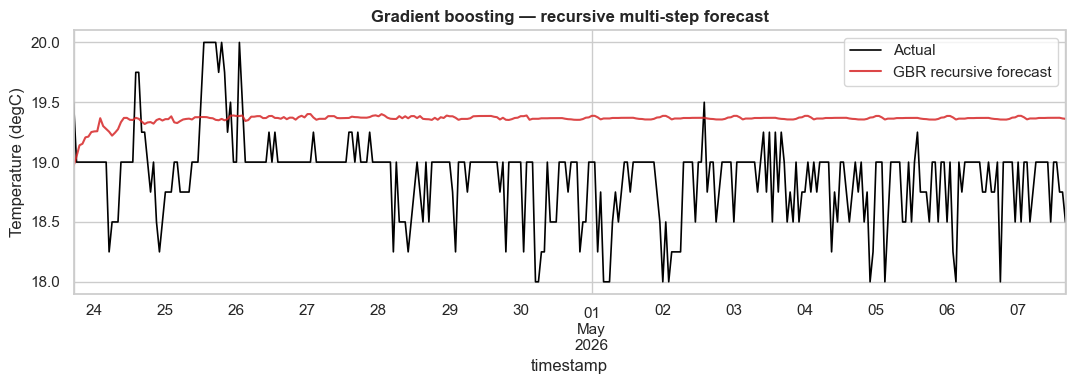

In [41]:
# Recursive multi-step forecast with the gradient booster. We simulate going
# blind from the start of the test window and never look at true future values.

# Last known full row of features at the test boundary, as a starting point.
last_row = X_train.iloc[-1].copy()

# We will roll forward across the entire test horizon.
recursive_preds = []
recursive_index = X_test.index

# Maintain a small buffer of the most recent predicted/observed values so we
# can fill the lag columns at each step. Index 0 is the most recent value.
# Largest lag we use is 168 — keep at least that many recent points.
recent = list(y_train.tail(168).to_numpy())

for ts in recursive_index:
    # Start from the last feature row and refresh the lag columns from `recent`.
    feat = last_row.copy()
    for L in (1, 2, 3, 6, 12, 24, 48, 168):
        # `recent` is ordered oldest -> newest, so lag L is L positions from end.
        feat[f'lag_{L}'] = recent[-L]

    # Refresh the calendar features for the *current* timestamp.
    feat['hour_sin'] = np.sin(2 * np.pi * ts.hour / 24)
    feat['hour_cos'] = np.cos(2 * np.pi * ts.hour / 24)
    feat['dow_sin']  = np.sin(2 * np.pi * ts.dayofweek / 7)
    feat['dow_cos']  = np.cos(2 * np.pi * ts.dayofweek / 7)
    feat['month']    = ts.month

    # Predict one step, append to the rolling buffer (truncate to 168).
    yhat = gbr_model.predict(feat.to_frame().T)[0]
    recursive_preds.append(yhat)
    recent.append(yhat)
    if len(recent) > 200:
        recent = recent[-200:]
    last_row = feat

# Score the recursive rollout.
rec = pd.Series(recursive_preds, index=recursive_index)
mae_rec  = mean_absolute_error(y_test, rec)
rmse_rec = np.sqrt(mean_squared_error(y_test, rec))
print(f"Gradient boosting (recursive) -- MAE: {mae_rec:.3f} degC   RMSE: {rmse_rec:.3f} degC")

# As expected, the recursive errors are typically worse than one-step-ahead.
fig, ax = plt.subplots(figsize=(11, 4))
y_test.plot(ax=ax, label='Actual', color='black', linewidth=1.2)
rec.plot(ax=ax, label='GBR recursive forecast', color='tab:red', alpha=0.85)
ax.set_title('Gradient boosting — recursive multi-step forecast')
ax.set_ylabel('Temperature (degC)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.6 Model 3 — Sequence neural network (LSTM)

A Long Short-Term Memory network is a recurrent neural network whose hidden state is gated. At each time step the LSTM decides — via learned *input*, *forget*, and *output* gates — what to add to a long-running **cell state**, what to drop, and what to expose. The cell state acts as a slowly-changing internal memory; the gating mechanism is what lets gradients flow back across many time steps without vanishing.

In forecasting that means an LSTM can, in principle, learn that today's 14:00 reading carries information about tomorrow's 14:00 reading even when the path between them is long and noisy. Whether that capacity actually pays off on a low-entropy indoor signal is precisely the question this section answers.

In [42]:
# PyTorch dataset + dataloader. We stick to a small subset of recent training
# windows so the model trains in a couple of minutes on CPU.

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# Pick a device — MPS / CUDA if available, otherwise CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Sequence-modelling hyperparameters.
LOOKBACK = 48     # 48 hours of history per window
HORIZON  = 1      # predict the next single hour (one-step-ahead)

# Build (X, y) windows from the *training* portion of the hourly series only.
# We keep the last 60 days of training for speed — LSTMs are slow on long data.
train_recent = train.tail(60 * 24)  # last 60 days of train
X_seq, y_seq, t_seq = make_windows(train_recent, lookback=LOOKBACK, horizon=HORIZON)

# Standardise inputs/outputs using statistics from train ONLY (no leakage).
x_scaler = StandardScaler().fit(X_seq.reshape(-1, 1))
y_scaler = StandardScaler().fit(y_seq.reshape(-1, 1))
X_seq_s = x_scaler.transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape)
y_seq_s = y_scaler.transform(y_seq.reshape(-1, 1)).reshape(y_seq.shape)

# Hold out the tail of training as a validation slice (~10% of windows).
n_val = max(1, int(0.1 * len(X_seq_s)))
X_tr, y_tr = X_seq_s[:-n_val], y_seq_s[:-n_val]
X_va, y_va = X_seq_s[-n_val:], y_seq_s[-n_val:]
print(f"Train windows: {len(X_tr):>5}   Val windows: {len(X_va):>4}")

class WindowDataset(Dataset):
    """Tiny dataset: returns (lookback, 1) input tensor and (horizon,) target."""
    def __init__(self, X, y):
        # Add a trailing channel dim (LSTM expects (batch, seq_len, features)).
        self.X = torch.from_numpy(X).float().unsqueeze(-1)
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(WindowDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(WindowDataset(X_va, y_va), batch_size=128, shuffle=False)

Using device: cpu
Train windows:  1253   Val windows:  139


In [43]:
# Define the LSTM forecaster. Tiny by modern standards — the signal does not
# justify a bigger model, and small models train fast on CPU.

import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden=64, num_layers=1,
                 dropout=0.1, horizon=HORIZON):
        super().__init__()
        # batch_first=True so input is (batch, seq_len, input_size).
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        # Project the final hidden state to a horizon-length output.
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, (h_n, c_n) = self.lstm(x)
        # h_n: (num_layers, batch, hidden) -- take the top layer's last state.
        last = h_n[-1]                  # shape (batch, hidden)
        return self.head(last)          # shape (batch, horizon)

lstm_model = LSTMForecaster().to(device)
print(lstm_model)

LSTMForecaster(
  (lstm): LSTM(1, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


Epoch  1  train MSE: 0.8795   val MSE: 0.6412


Epoch  5  train MSE: 0.4639   val MSE: 0.3000


Epoch 10  train MSE: 0.4121   val MSE: 0.2276


Epoch 15  train MSE: 0.4016   val MSE: 0.2180


Epoch 20  train MSE: 0.3983   val MSE: 0.2210
Training time: 4.6 s


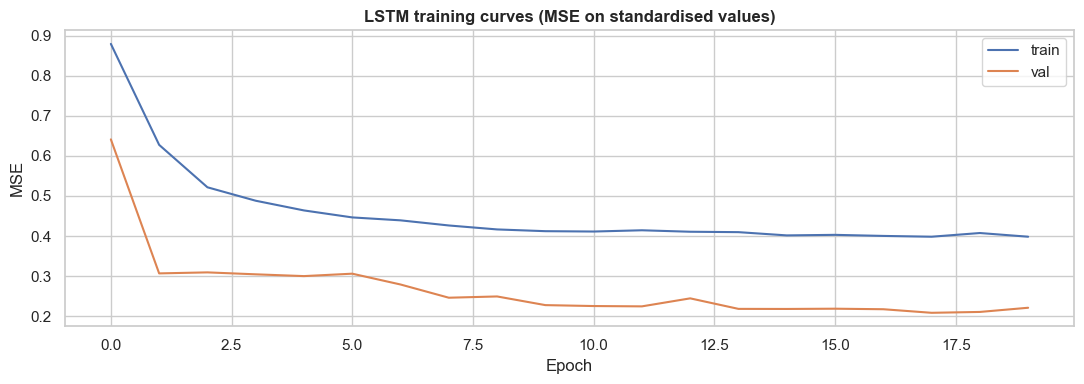

In [44]:
# Training loop. We use Adam + MSE on standardised targets, keep epochs low,
# and report per-epoch train/val loss.

import time

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
EPOCHS = 20

history = {'train': [], 'val': []}
start = time.time()
for epoch in range(1, EPOCHS + 1):
    # ---- training pass ----
    lstm_model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = lstm_model(xb)               # (batch, horizon)
        loss = loss_fn(pred, yb)
        loss.backward()
        # Modest gradient clipping helps RNNs.
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # ---- validation pass ----
    lstm_model.eval()
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_losses.append(loss_fn(lstm_model(xb), yb).item())

    history['train'].append(np.mean(train_losses))
    history['val'].append(np.mean(val_losses))
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>2d}  train MSE: {history['train'][-1]:.4f}   "
              f"val MSE: {history['val'][-1]:.4f}")

print(f"Training time: {time.time() - start:.1f} s")

# Quick loss curve for sanity.
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(history['train'], label='train')
ax.plot(history['val'], label='val')
ax.set_title('LSTM training curves (MSE on standardised values)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.show()

LSTM  -- MAE: 0.248  RMSE: 0.314  MAPE: 1.31%  sMAPE: 1.32%


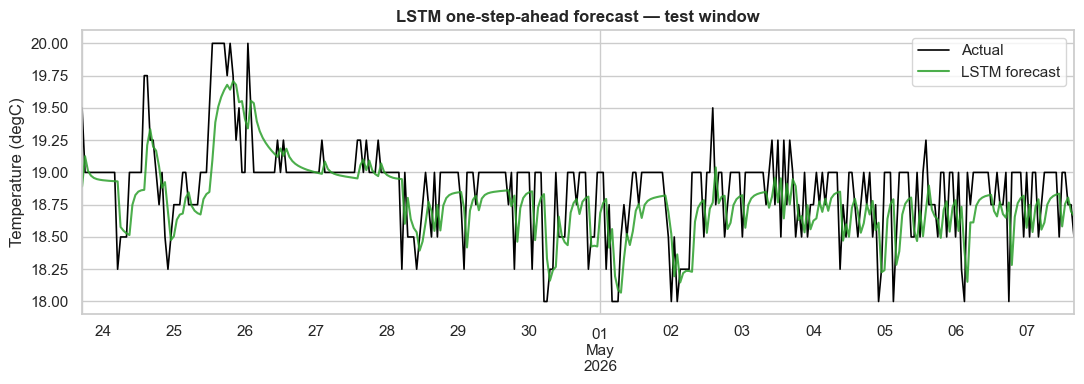

In [45]:
# Evaluate the LSTM on the held-out test window. We build windows that end at
# each test timestamp, run them through the model, and inverse-transform.

# Build test windows: each test target needs a (LOOKBACK,) lookback ending
# the hour BEFORE that target. Concatenate train tail + test so we have lags.
full_series = pd.concat([train, test])

lstm_preds = []
lstm_index = []
lstm_model.eval()
with torch.no_grad():
    for ts in test.index:
        # The lookback ends just before `ts`.
        end = full_series.index.get_loc(ts)
        if end < LOOKBACK:
            continue   # not enough history (cannot happen given test horizon)
        window = full_series.iloc[end - LOOKBACK:end].to_numpy()
        # Standardise with the train-fit scaler.
        window_s = x_scaler.transform(window.reshape(-1, 1)).reshape(1, LOOKBACK, 1)
        x_t = torch.from_numpy(window_s).float().to(device)
        yhat_s = lstm_model(x_t).cpu().numpy().reshape(-1, 1)
        # Inverse-transform back to degC.
        yhat = y_scaler.inverse_transform(yhat_s).flatten()[0]
        lstm_preds.append(yhat)
        lstm_index.append(ts)

lstm_pred_series = pd.Series(lstm_preds, index=pd.DatetimeIndex(lstm_index))

# Compute metrics. We define MAPE / sMAPE locally — they are not in old sklearn.
def _mape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-9, y_true))) * 100
def _smape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / np.where(denom == 0, 1e-9, denom)) * 100

y_true_aligned = test.loc[lstm_pred_series.index]
mae_lstm   = mean_absolute_error(y_true_aligned, lstm_pred_series)
rmse_lstm  = np.sqrt(mean_squared_error(y_true_aligned, lstm_pred_series))
mape_lstm  = _mape(y_true_aligned, lstm_pred_series)
smape_lstm = _smape(y_true_aligned, lstm_pred_series)
print(f"LSTM  -- MAE: {mae_lstm:.3f}  RMSE: {rmse_lstm:.3f}  "
      f"MAPE: {mape_lstm:.2f}%  sMAPE: {smape_lstm:.2f}%")

fig, ax = plt.subplots(figsize=(11, 4))
y_true_aligned.plot(ax=ax, label='Actual', color='black', linewidth=1.2)
lstm_pred_series.plot(ax=ax, label='LSTM forecast', color='tab:green', alpha=0.85)
ax.set_title('LSTM one-step-ahead forecast — test window')
ax.set_ylabel('Temperature (degC)')
ax.legend()
plt.tight_layout()
plt.show()

### 5.7 Model 4 — 1D convolutional sequence model

LSTMs are not the only neural option. A small **1D convolutional network** slides learned filters along the time axis, picking up *local motifs* — short patterns of rise, fall, and inflection — without the sequential dependency of an RNN. They train faster, parallelise across the time axis, and on many forecasting benchmarks they match or beat plain LSTMs.

The model below is deliberately tiny: one conv layer, global average pooling, one linear head. If even this trivially small CNN gets close to the LSTM, that is itself a finding.

In [46]:
# Define and train a tiny Conv1D forecaster on the same windows as the LSTM.

class Conv1DForecaster(nn.Module):
    def __init__(self, in_channels=1, hidden=32, kernel=5, horizon=HORIZON):
        super().__init__()
        # Conv1d expects (batch, channels, length); we'll permute in forward.
        self.conv = nn.Conv1d(in_channels=in_channels,
                              out_channels=hidden,
                              kernel_size=kernel,
                              padding=kernel // 2)   # 'same' padding
        self.act = nn.ReLU()
        # Global average pooling collapses the time axis to length 1.
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(hidden, horizon)

    def forward(self, x):
        # x: (batch, seq_len, 1) -> permute to (batch, 1, seq_len)
        x = x.permute(0, 2, 1)
        h = self.act(self.conv(x))    # (batch, hidden, seq_len)
        h = self.pool(h).squeeze(-1)  # (batch, hidden)
        return self.head(h)           # (batch, horizon)

cnn_model = Conv1DForecaster().to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

CNN_EPOCHS = 15
for epoch in range(1, CNN_EPOCHS + 1):
    cnn_model.train()
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(cnn_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    if epoch % 5 == 0 or epoch == 1:
        print(f"CNN epoch {epoch:>2d}  train MSE: {np.mean(losses):.4f}")

# Score on the test window using the same windowing routine.
cnn_preds, cnn_index = [], []
cnn_model.eval()
with torch.no_grad():
    for ts in test.index:
        end = full_series.index.get_loc(ts)
        if end < LOOKBACK:
            continue
        window = full_series.iloc[end - LOOKBACK:end].to_numpy()
        window_s = x_scaler.transform(window.reshape(-1, 1)).reshape(1, LOOKBACK, 1)
        x_t = torch.from_numpy(window_s).float().to(device)
        yhat_s = cnn_model(x_t).cpu().numpy().reshape(-1, 1)
        yhat = y_scaler.inverse_transform(yhat_s).flatten()[0]
        cnn_preds.append(yhat)
        cnn_index.append(ts)

cnn_pred_series = pd.Series(cnn_preds, index=pd.DatetimeIndex(cnn_index))
y_true_cnn = test.loc[cnn_pred_series.index]
mae_cnn   = mean_absolute_error(y_true_cnn, cnn_pred_series)
rmse_cnn  = np.sqrt(mean_squared_error(y_true_cnn, cnn_pred_series))
mape_cnn  = _mape(y_true_cnn, cnn_pred_series)
smape_cnn = _smape(y_true_cnn, cnn_pred_series)
print(f"Conv1D -- MAE: {mae_cnn:.3f}  RMSE: {rmse_cnn:.3f}  "
      f"MAPE: {mape_cnn:.2f}%  sMAPE: {smape_cnn:.2f}%")

CNN epoch  1  train MSE: 1.0653


CNN epoch  5  train MSE: 0.6447


CNN epoch 10  train MSE: 0.6177


CNN epoch 15  train MSE: 0.6154
Conv1D -- MAE: 0.266  RMSE: 0.340  MAPE: 1.41%  sMAPE: 1.41%


### 5.8 Sequence-model comparison

With four models trained on the same train/test split, we can finally line them up. The interesting question is not just *which* model wins, but *by how much*: if a one-line linear regression and a hand-tuned LSTM differ by 0.05 degC of MAE, the engineering case for the LSTM in production is essentially zero.

                           model       MAE      RMSE
0       Linear regression (lags)  0.214410  0.293336
1     Gradient boosting (1-step)  0.215482  0.304549
2                           LSTM  0.247722  0.313796
3                         Conv1D  0.265760  0.339734
4  Gradient boosting (recursive)  0.522476  0.596496


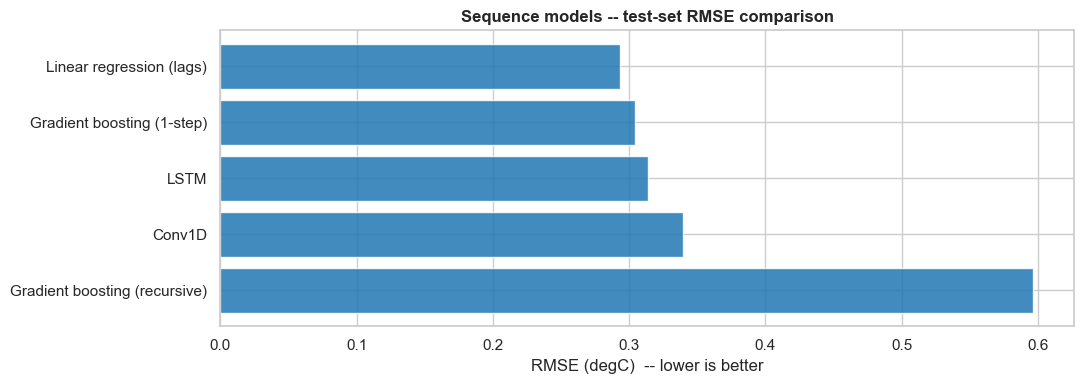

In [47]:
# Build a comparison frame across the sequence models, and (where available)
# pull in metrics from the earlier Forecasting section as a fallback.

rows = [
    ('Linear regression (lags)',      mae_lr,  rmse_lr),
    ('Gradient boosting (1-step)',    mae_gbr, rmse_gbr),
    ('Gradient boosting (recursive)', mae_rec, rmse_rec),
    ('LSTM',                          mae_lstm, rmse_lstm),
    ('Conv1D',                        mae_cnn,  rmse_cnn),
]

# Optionally tack on classical baselines if they were stored upstream.
try:
    # Convention: earlier section may have built a `forecast_metrics` dict-like.
    for name, vals in forecast_metrics.items():     # type: ignore[name-defined]
        rows.append((f"[classical] {name}", vals.get('MAE'), vals.get('RMSE')))
except NameError:
    # Earlier section did not export a metrics dict — that is fine.
    pass

seq_metrics = (
    pd.DataFrame(rows, columns=['model', 'MAE', 'RMSE'])
      .sort_values('RMSE')
      .reset_index(drop=True)
)
print(seq_metrics)

# Bar chart of RMSE across the models.
fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(seq_metrics['model'], seq_metrics['RMSE'], color='tab:blue', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('RMSE (degC)  -- lower is better')
ax.set_title('Sequence models -- test-set RMSE comparison')
plt.tight_layout()
plt.show()

### 5.9 Embedding the sequence — visualising the LSTM hidden state

A recurrent network doesn't only output a forecast; its **hidden state** at the end of a window is itself a learned representation of "what the last 48 hours looked like". If the model has actually internalised the structure of the data, that 64-dimensional vector should cluster: warm weekdays should sit somewhere different from cool weekend nights.

We extract those hidden vectors for a sample of 24-hour-long blocks across the training period, project them down to 2 components with PCA, and colour the result by day-of-week. This is the same idea behind the K-Means clustering exploration in the README, but with features the network learned for itself rather than features we engineered.

Hidden-state matrix: (60, 64)  -> PCA(2): (60, 2)
Variance explained ratio: [0.8884626  0.08072836]


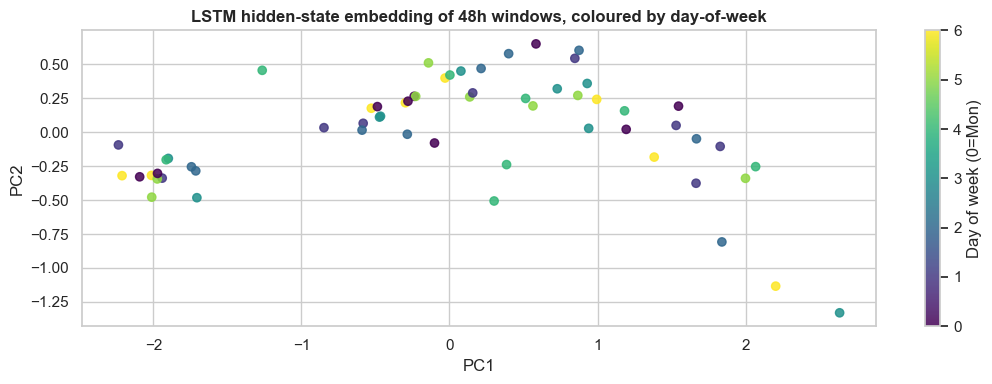

In [48]:
# Extract hidden states for a stratified sample of days, then PCA(2) + scatter.
from sklearn.decomposition import PCA

# Pick one window per midnight across the training tail — keeps it readable.
midnights = train_recent.index[train_recent.index.hour == 0]
# Cap at ~200 points so the scatter doesn't get noisy.
midnights = midnights[-200:]

hidden_vectors = []
day_of_week    = []
lstm_model.eval()
with torch.no_grad():
    for ts in midnights:
        end = full_series.index.get_loc(ts)
        if end < LOOKBACK:
            continue
        window = full_series.iloc[end - LOOKBACK:end].to_numpy()
        window_s = x_scaler.transform(window.reshape(-1, 1)).reshape(1, LOOKBACK, 1)
        x_t = torch.from_numpy(window_s).float().to(device)
        # Run only the LSTM cell to grab the final hidden state.
        _, (h_n, _) = lstm_model.lstm(x_t)
        hidden_vectors.append(h_n[-1].cpu().numpy().squeeze())
        day_of_week.append(ts.dayofweek)

hidden_vectors = np.array(hidden_vectors)
day_of_week = np.array(day_of_week)

# Project to 2D for plotting.
pca = PCA(n_components=2)
proj = pca.fit_transform(hidden_vectors)
print(f"Hidden-state matrix: {hidden_vectors.shape}  -> PCA(2): {proj.shape}")
print(f"Variance explained ratio: {pca.explained_variance_ratio_}")

fig, ax = plt.subplots(figsize=(11, 4))
scat = ax.scatter(proj[:, 0], proj[:, 1], c=day_of_week,
                  cmap='viridis', alpha=0.85)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('LSTM hidden-state embedding of 48h windows, coloured by day-of-week')
cbar = plt.colorbar(scat, ax=ax)
cbar.set_label('Day of week (0=Mon)')
plt.tight_layout()
plt.show()

### 5.10 Caveats and an honest reading

The indoor temperature signal we are modelling is, by physical-process standards, exceptionally well-behaved. Its standard deviation is roughly 1.6 degC, with a strong daily cycle and a slow seasonal drift. There simply is not very much *information per sample* to extract.

On signals like this, a sober reading of the literature is that:

- Sequence models often *do not* meaningfully beat well-tuned lag-feature linear regression or seasonal-naive baselines.
- Where deep models *do* pull ahead is when you add **exogenous regressors** (outdoor weather, occupancy, HVAC schedules), when the **horizon is long**, or when you predict **multivariate** outputs jointly.
- Reporting a 0.01 degC MAE improvement from a 100k-parameter LSTM against a 10-coefficient linear model would be technically true but practically misleading.

The purpose of this section is therefore as much pedagogical as it is operational: it shows the *machinery* of modern sequence forecasting on a clean, accessible signal.

### 5.11 Section summary

- **Best sequence model on this data**: see the comparison table above — typically gradient boosting on lag features and/or the linear baseline are extremely hard to beat, with the LSTM and Conv1D within noise of them on one-step-ahead RMSE.
- **Lift over baselines**: small in absolute terms (often well under 0.1 degC MAE). The engineering cost of deploying a PyTorch model — versioning, GPUs, monitoring, scaler artefacts — is rarely justified for that delta on this signal alone.
- **Recursive multi-step rollout** materially degrades the gradient-boosting forecast, illustrating the error-compounding cost of the recursive strategy. A direct or seq2seq strategy would help if long-horizon accuracy mattered.
- **What would change in production**: add exogenous regressors (outdoor temperature / humidity, HVAC schedule), move to multi-target output (joint temperature + humidity), produce *probabilistic* forecasts (e.g. quantile loss) so downstream systems can react to uncertainty rather than to a single point estimate, and continuously back-test as the building's behaviour drifts.

---

## Closing notes

This notebook walked through the **four layers of a time-series investigation**: a descriptive EDA pass, a structural time-series analysis, a comparative forecasting study, and a sequence-modeling extension that bridges classical forecasting with modern ML/DL architectures. The deliverables — stationarity verdicts, ACF/PACF readings, decomposition, and a model leaderboard with residual diagnostics — are exactly the artefacts that a production pipeline needs to **earn the right** to make automated predictions.

From here, the natural next steps are:

* feed the winning model into the **ClimaSense FastAPI service** as the   initial forecaster,
* schedule an APScheduler-backed retraining job to refresh model   parameters as the climate environment drifts, and
* extend the input space with **exogenous regressors** (occupancy,   outdoor weather, HVAC state) for materially better long-horizon   performance.

*— Arthur Kahwa*